# Nexus — Globant Shelf Optimization
## Objectives 3 & 4: Product-Level Safety Stock + Live Alert Engine + Phantom Inventory Detection
### Single Store | Category & Product Priority View | Team 2 | University at Buffalo

---

| | |
|---|---|
| **Client** | Globant AI Studios — James Partsch, Roberto Contreras |
| **Focus** | Auto-selects store with highest urgency score |
| **Service Level** | 97.5% → Z = 1.96 (Section 7, Shelf Optimization Data Guide) |
| **Alert Time** | Live — current system timestamp |
| **New in this version** | Product-level view, category drill-down, phantom inventory detection, reliable priority ordering |

---

**What this notebook does in plain English:**

- **Objective 3:** Calculates the exact buffer stock each product needs so 97.5% of the time it is always available
- **Objective 4:** Generates a live ranked alert report — most urgent product at the top — with full product and category breakdown
- **Phantom Detection:** Finds products the system shows as in-stock but that are not actually selling (ghost inventory)
- **Priority Ordering:** Ranks by 5 reliable factors — tier urgency, revenue loss, days remaining, supplier reliability, seasonal demand

---
## Section 0 — Imports and Configuration

> **What this cell does:** Loads all libraries and sets every business rule in one place.

> **Z = 1.96** comes from the normal distribution table for 97.5% service level — specified in Section 7 of the Globant Data Guide.

> Change any threshold here and the entire system updates automatically — no other cells need editing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
from pathlib import Path
from scipy import stats
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── UPDATE THIS PATH TO YOUR LOCAL CSV FOLDER ────────────────────
DATA_DIR   = Path('/Users/shashi/retail-ai-project/data/raw/output/csv')
OUTPUT_DIR = Path('./nexus_alert_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── SERVICE LEVEL — from Section 7, Globant Data Guide ───────────
SERVICE_LEVEL = 0.975
Z_SCORE       = stats.norm.ppf(SERVICE_LEVEL)  # 1.9600

# ── ALERT THRESHOLDS (days of supply) ────────────────────────────
CRITICAL_DAYS = 3
WARNING_DAYS  = 7
MONITOR_DAYS  = 14
TARGET_DAYS   = 14

# ── PHANTOM DETECTION THRESHOLD ──────────────────────────────────
PHANTOM_SLOW_MOVER_PCT = 0.05  # exclude bottom 5th percentile sellers

# ── PRIORITY WEIGHTS (5 reliable factors) ────────────────────────
TIER_WEIGHT   = {'CRITICAL': 1000, 'WARNING': 100, 'MONITOR': 10, 'OK': 0}
REV_RISK_DIV  = 1000   # scale revenue at risk into score
DOS_WEIGHT    = 5      # lower days of supply = higher score
SUPP_WEIGHT   = 20     # lower supplier reliability = higher score
SEASON_WEIGHT = 10     # higher seasonal demand = higher score

# ── CURRENT TIME ─────────────────────────────────────────────────
NOW       = datetime.now()
TODAY     = pd.Timestamp.today().normalize()
LOOKAHEAD = TODAY + timedelta(days=7)

# ── COLOR PALETTE ─────────────────────────────────────────────────
AC = {
    'CRITICAL' : '#DC2626',
    'WARNING'  : '#D97706',
    'MONITOR'  : '#7C3AED',
    'OK'       : '#059669',
    'PHANTOM'  : '#0891B2',
    'navy'     : '#1A2B4A',
    'teal'     : '#0D9488',
    'light'    : '#F8FAFC',
}

plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
})

month_names = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
    7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'
}
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

print('=' * 62)
print('  NEXUS | SHELF ALERT SYSTEM — PRODUCT LEVEL VIEW')
print('=' * 62)
print(f'  Generated      : {NOW.strftime("%A, %B %d, %Y at %I:%M %p")}')
print(f'  Service Level  : {SERVICE_LEVEL*100:.1f}%  Z = {Z_SCORE:.4f}')
print(f'  CRITICAL       : days_of_supply <= {CRITICAL_DAYS}')
print(f'  WARNING        : days_of_supply <= {WARNING_DAYS}')
print(f'  MONITOR        : days_of_supply <= {MONITOR_DAYS}')
print(f'  Order Target   : {TARGET_DAYS} days of supply after delivery')
print(f'  Phantom Excl.  : bottom {PHANTOM_SLOW_MOVER_PCT*100:.0f}th percentile weekly sellers')
print('=' * 62)


  NEXUS | SHELF ALERT SYSTEM — PRODUCT LEVEL VIEW
  Generated      : Saturday, April 25, 2026 at 01:19 PM
  Service Level  : 97.5%  Z = 1.9600
  CRITICAL       : days_of_supply <= 3
  MONITOR        : days_of_supply <= 14
  Order Target   : 14 days of supply after delivery
  Phantom Excl.  : bottom 5th percentile weekly sellers


---
## Section 1 — Load All Datasets

> **What this cell does:** Loads all 8 datasets. sales_transactions.csv is ~2GB so we load it in 500,000-row chunks — like reading a 2,000-page book 100 pages at a time and taking notes as you go.

> We also build weekly sales aggregations here, which the phantom inventory detection uses later.

In [2]:
# ── Reference tables ─────────────────────────────────────────────
stores     = pd.read_csv(DATA_DIR / 'stores.csv',    parse_dates=['open_date'])
products   = pd.read_csv(DATA_DIR / 'products.csv')
suppliers  = pd.read_csv(DATA_DIR / 'suppliers.csv', parse_dates=['contract_start'])
inv_snap   = pd.read_csv(DATA_DIR / 'inventory_snapshots.csv',
                          parse_dates=['snapshot_date','expiry_nearest_date'])
repl_logs  = pd.read_csv(DATA_DIR / 'replenishment_logs.csv',
                          parse_dates=['replenishment_date','order_date','receive_date'])
stockout   = pd.read_csv(DATA_DIR / 'stockout_events.csv',
                          parse_dates=['stockout_date','restock_date'])
promotions = pd.read_csv(DATA_DIR / 'promotions.csv',
                          parse_dates=['start_date','end_date'])

# ── Sales — chunked load ──────────────────────────────────────────
print('Loading sales_transactions.csv in 500K-row chunks...')
chunks = []
for chunk in pd.read_csv(
        DATA_DIR / 'sales_transactions.csv',
        parse_dates=['sale_date'], chunksize=500_000):
    grp = (chunk
           .groupby(['store_id','sku_id','sale_date'])
           .agg(units_sold=('units_sold','sum'), revenue=('revenue','sum'))
           .reset_index())
    chunks.append(grp)

sales = (pd.concat(chunks)
           .groupby(['store_id','sku_id','sale_date'])
           .agg(units_sold=('units_sold','sum'), revenue=('revenue','sum'))
           .reset_index())

# ── Time columns for seasonal analysis ───────────────────────────
sales['month']   = sales['sale_date'].dt.month
sales['month_nm']= sales['sale_date'].dt.strftime('%b')
sales['dow']     = sales['sale_date'].dt.dayofweek
sales['dow_nm']  = sales['sale_date'].dt.strftime('%a')
sales['week']    = sales['sale_date'].dt.to_period('W')
sales['year']    = sales['sale_date'].dt.year

# ── Weekly sales — used by phantom detection ──────────────────────
sales_weekly = (sales
    .groupby(['store_id','sku_id','week'])
    .agg(weekly_units=('units_sold','sum'))
    .reset_index())

print()
print('ALL DATASETS LOADED:')
print(f'  Stores              : {len(stores):,}')
print(f'  Products (SKUs)     : {len(products):,}')
print(f'  Suppliers           : {len(suppliers):,}')
print(f'  Sales (daily agg)   : {len(sales):,} rows')
print(f'  Inventory snapshots : {len(inv_snap):,} rows')
print(f'  Replenishment logs  : {len(repl_logs):,} rows')
print(f'  Stockout events     : {len(stockout):,} rows')
print(f'  Promotions          : {len(promotions):,} rows')
print(f'  Weekly sales (phantom use): {len(sales_weekly):,} rows')
print(f'  Date range : {sales["sale_date"].min().date()} to {sales["sale_date"].max().date()}')


Loading sales_transactions.csv in 500K-row chunks...

ALL DATASETS LOADED:
  Stores              : 478
  Products (SKUs)     : 1,265
  Suppliers           : 85
  Sales (daily agg)   : 25,969,106 rows
  Inventory snapshots : 4,015,200 rows
  Replenishment logs  : 1,366,761 rows
  Stockout events     : 313,599 rows
  Promotions          : 5,420 rows
  Weekly sales (phantom use): 3,993,125 rows
  Date range : 2024-01-01 to 2025-12-31


---
## Section 2 — Auto-Select the Most Urgent Store

> **What this cell does:** Scores every store using three factors and picks the one that needs the most attention.

> **Urgency score = (lost_revenue / 1000) + (total_events x 10) + (ongoing_stockouts x 100)**

> Ongoing stockouts get the highest weight because they represent active revenue loss happening right now.

In [3]:
store_score = (
    stockout.groupby('store_id')
    .agg(
        total_events   = ('stockout_id',           'count'),
        total_lost_rev = ('estimated_lost_revenue', 'sum'),
        avg_duration   = ('duration_days',          'mean'),
        ongoing        = ('restock_date', lambda x: x.isnull().sum()),
    )
    .reset_index()
)

store_score['urgency_score'] = (
    store_score['total_lost_rev'] / 1000 +
    store_score['total_events']   * 10 +
    store_score['ongoing']        * 100
)

FOCUS_STORE = store_score.nlargest(1, 'urgency_score').iloc[0]['store_id']
store_info  = stores[stores['store_id'] == FOCUS_STORE].iloc[0]
this_score  = store_score[store_score['store_id'] == FOCUS_STORE].iloc[0]

# Filter all data to this one store
s_sales = sales[sales['store_id']     == FOCUS_STORE].copy()
s_so    = stockout[stockout['store_id']  == FOCUS_STORE].copy()
s_repl  = repl_logs[repl_logs['store_id']== FOCUS_STORE].copy()
s_snap  = inv_snap[inv_snap['store_id']  == FOCUS_STORE].copy()
s_weekly= sales_weekly[sales_weekly['store_id'] == FOCUS_STORE].copy()

print('=' * 62)
print(f'  FOCUS STORE: {FOCUS_STORE}')
print('=' * 62)
print(f'  Name         : {store_info["store_name"]}')
print(f'  City / State : {store_info["city"]}, {store_info["state"]}')
print(f'  Region       : {store_info["region"]}')
print(f'  Format       : {store_info["store_format"]}')
print(f'  Traffic Tier : {store_info["foot_traffic_tier"]}')
print()
print('WHY THIS STORE:')
print(f'  Stockout events   : {int(this_score["total_events"]):,}')
print(f'  Total lost revenue: ${this_score["total_lost_rev"]:,.0f}')
print(f'  Ongoing right now : {int(this_score["ongoing"])}')
print(f'  Avg duration      : {this_score["avg_duration"]:.1f} days')
print()
print('DATA FOR THIS STORE:')
print(f'  Sales records  : {len(s_sales):,}')
print(f'  Stockout events: {len(s_so):,}')
print(f'  Replenishments : {len(s_repl):,}')
print(f'  Inv snapshots  : {len(s_snap):,}')
print(f'  Unique SKUs    : {s_sales["sku_id"].nunique():,}')


  FOCUS STORE: S0064
  Name         : GoldenSquare Houston
  City / State : Houston, TX
  Region       : Southwest
  Format       : Hypermarket
  Traffic Tier : Premium

WHY THIS STORE:
  Stockout events   : 1,535
  Total lost revenue: $2,836,218
  Ongoing right now : 12
  Avg duration      : 4.1 days

DATA FOR THIS STORE:
  Sales records  : 54,254
  Stockout events: 1,535
  Replenishments : 4,031
  Inv snapshots  : 8,400
  Unique SKUs    : 80


---
## Section 3 — Seasonal Demand Analysis

> **What this cell does:** Measures when demand is highest by month and by day of week.

> **Why this matters for alerts:** A product with 7 days of supply in December (peak month) is MORE critical than the same product in February (lowest month). The seasonal factor adjusts safety stock and order quantities accordingly.

> **Demand index of 130** means that month sells 30% more than average — safety stock needs to be 30% higher.

In [4]:
# ── Monthly demand index ──────────────────────────────────────────
monthly_avg     = s_sales.groupby('month')['units_sold'].mean()
overall_avg     = s_sales['units_sold'].mean()
monthly_idx     = (monthly_avg / overall_avg * 100).round(1)

# ── Day of week index ─────────────────────────────────────────────
dow_avg         = s_sales.groupby('dow')['units_sold'].mean()
dow_idx         = (dow_avg / overall_avg * 100).round(1)

peak_month      = int(monthly_avg.idxmax())
low_month       = int(monthly_avg.idxmin())
peak_dow        = int(dow_avg.idxmax())
seasonal_factor = monthly_idx.get(TODAY.month, 100) / 100

swing = (monthly_avg.max() - monthly_avg.min()) / monthly_avg.min() * 100

print(f'SEASONAL ANALYSIS — Store {FOCUS_STORE}')
print(f'  Overall avg daily demand : {overall_avg:.1f} units/day')
print(f'  Current month ({month_names[TODAY.month]}) index : {monthly_idx.get(TODAY.month,100):.1f}')
print(f'  Seasonal factor applied  : {seasonal_factor:.3f}')
print(f'  Seasonal swing           : {swing:.1f}%')
print(f'  Peak month               : {month_names[peak_month]} ({monthly_idx[peak_month]:.1f})')
print(f'  Lowest month             : {month_names[low_month]} ({monthly_idx[low_month]:.1f})')
print(f'  Peak day of week         : {dow_labels[peak_dow]} ({dow_idx[peak_dow]:.1f})')
print()
print('MONTHLY DEMAND INDEX (100 = average):')
for m, idx in monthly_idx.items():
    bar  = chr(9608) * int(idx / 10)
    flag = ' <- PEAK'   if m == peak_month else (' <- LOWEST' if m == low_month else '')
    now_flag = ' <- NOW' if m == TODAY.month else ''
    print(f'  {month_names[m]:<4}: {idx:>6.1f}  {bar}{flag}{now_flag}')


SEASONAL ANALYSIS — Store S0064
  Overall avg daily demand : 18.2 units/day
  Current month (Apr) index : 91.3
  Seasonal factor applied  : 0.913
  Seasonal swing           : 53.3%
  Peak month               : Dec (129.5)
  Lowest month             : Feb (84.5)
  Peak day of week         : Sat (122.8)

MONTHLY DEMAND INDEX (100 = average):
  Jan :   86.4  ████████
  Feb :   84.5  ████████ <- LOWEST
  Mar :   91.6  █████████
  Apr :   91.3  █████████ <- NOW
  May :   97.0  █████████
  Jun :  101.2  ██████████
  Jul :  105.0  ██████████
  Aug :  104.5  ██████████
  Sep :   93.9  █████████
  Oct :   99.2  █████████
  Nov :  116.9  ███████████
  Dec :  129.5  ████████████ <- PEAK


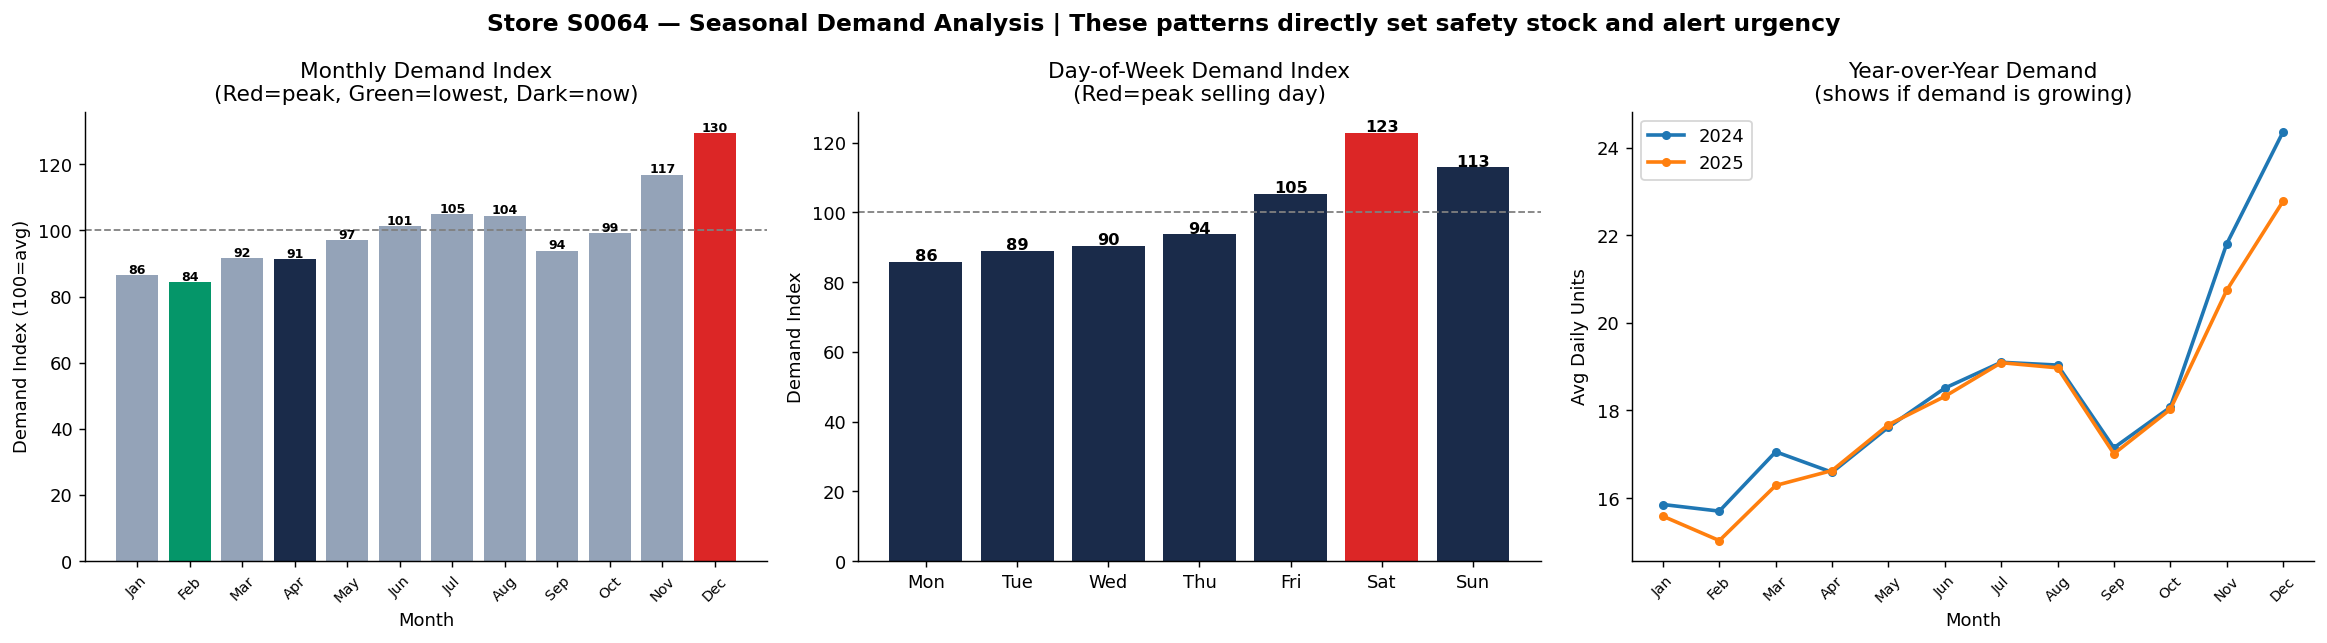

Saved: 01_seasonal_analysis.png


In [5]:
# ── Seasonal chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f'Store {FOCUS_STORE} — Seasonal Demand Analysis | '
    f'These patterns directly set safety stock and alert urgency',
    fontsize=13, fontweight='bold')

# Monthly index
ax = axes[0]
mcolors = []
for m in range(1, 13):
    if m == peak_month:
        mcolors.append(AC['CRITICAL'])
    elif m == low_month:
        mcolors.append(AC['OK'])
    elif m == TODAY.month:
        mcolors.append(AC['navy'])
    else:
        mcolors.append('#94A3B8')
bars = ax.bar(range(1, 13), monthly_idx.values, color=mcolors)
ax.axhline(100, color='gray', linestyle='--', linewidth=1)
ax.set_title('Monthly Demand Index\n(Red=peak, Green=lowest, Dark=now)')
ax.set_xlabel('Month')
ax.set_ylabel('Demand Index (100=avg)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names[m] for m in range(1, 13)], rotation=45, fontsize=8)
for bar, val in zip(bars, monthly_idx.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}', ha='center', fontsize=7, fontweight='bold')

# Day of week index
ax = axes[1]
dcolors = [AC['CRITICAL'] if d == peak_dow else AC['navy'] for d in range(7)]
bars2 = ax.bar(dow_labels, dow_idx.values, color=dcolors)
ax.axhline(100, color='gray', linestyle='--', linewidth=1)
ax.set_title('Day-of-Week Demand Index\n(Red=peak selling day)')
ax.set_ylabel('Demand Index')
for bar, val in zip(bars2, dow_idx.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')

# Year over year
ax = axes[2]
yoy = s_sales.groupby(['year','month'])['units_sold'].mean().reset_index()
for yr in sorted(yoy['year'].unique()):
    yd = yoy[yoy['year'] == yr]
    ax.plot(yd['month'], yd['units_sold'],
            marker='o', markersize=4, linewidth=2, label=str(yr))
ax.set_title('Year-over-Year Demand\n(shows if demand is growing)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Daily Units')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names[m] for m in range(1, 13)], rotation=45, fontsize=8)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_seasonal_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: 01_seasonal_analysis.png')


---
## Section 4 — Demand Statistics per Product

> **What this cell does:** For every product at this store calculates:
> - avg_daily_demand (D) = on average how many units sell per day
> - std_daily_demand (sigma) = how much daily sales vary — higher variance = more buffer needed
> - cv = coefficient of variation = std/mean — shows how erratic demand is
> - seasonal demand = D adjusted for current month demand index

> These numbers feed directly into the safety stock formula in Section 5.

In [6]:
demand_stats = (
    s_sales.groupby('sku_id')
    .agg(
        avg_daily_demand = ('units_sold', 'mean'),
        std_daily_demand = ('units_sold', 'std'),
        max_daily_demand = ('units_sold', 'max'),
        total_units      = ('units_sold', 'sum'),
        total_revenue    = ('revenue',    'sum'),
        demand_days      = ('units_sold', 'count'),
    )
    .reset_index()
)

demand_stats['std_daily_demand'] = demand_stats['std_daily_demand'].fillna(0)
demand_stats['cv'] = (
    demand_stats['std_daily_demand'] /
    demand_stats['avg_daily_demand'].replace(0, np.nan)
).fillna(0)

# Enrich with product and supplier info
prod_sup = products.merge(
    suppliers[['supplier_id','supplier_name','lead_time_days_avg',
               'lead_time_days_std','reliability_score']],
    on='supplier_id', how='left').drop_duplicates(subset='sku_id', keep='first')  # FIX: prevent duplicate merge crash

demand_stats = demand_stats.merge(
    prod_sup[['sku_id','product_name','category','subcategory',
              'unit_price','unit_cost','pack_size','reorder_point',
              'safety_stock','is_perishable','shelf_life_days',
              'supplier_id','supplier_name','lead_time_days_avg',
              'lead_time_days_std','reliability_score']],
    on='sku_id', how='left')

# Seasonal adjustment
demand_stats['seasonal_factor'] = seasonal_factor
demand_stats['avg_demand_seasonal'] = (
    demand_stats['avg_daily_demand'] * seasonal_factor
)

print(f'DEMAND STATS — Store {FOCUS_STORE}')
print(f'  Total products analyzed : {len(demand_stats):,}')
print(f'  High volatility (CV>1)  : {(demand_stats["cv"]>1).sum():,}')
print(f'  Seasonal factor ({month_names[TODAY.month]}): {seasonal_factor:.3f}')
print()
print('PRODUCT DEMAND TABLE — Top 15 by Revenue:')
print(f'  {"SKU":<10} {"Product":<32} {"Category":<18} {"Avg/day":>8} {"Std":>6} {"CV":>6} {"Revenue":>12}')
print(f'  {"-"*97}')
for _, r in demand_stats.nlargest(15, 'total_revenue').iterrows():
    pname = str(r.get('product_name',''))[:30]
    print(
        f'  {r["sku_id"]:<10}'
        f' {pname:<32}'
        f' {str(r["category"]):<18}'
        f' {r["avg_daily_demand"]:>8.1f}'
        f' {r["std_daily_demand"]:>6.1f}'
        f' {r["cv"]:>6.2f}'
        f' ${r["total_revenue"]:>11,.0f}'
    )


DEMAND STATS — Store S0064
  Total products analyzed : 80
  High volatility (CV>1)  : 0
  Seasonal factor (Apr): 0.913

PRODUCT DEMAND TABLE — Top 15 by Revenue:
  SKU        Product                          Category            Avg/day    Std     CV      Revenue
  -------------------------------------------------------------------------------------------------
  P00700     CoastalFarms Natural Toothpast   Personal Care          32.2   11.1   0.34 $  1,136,419
  P00702     BlueRidge Classic Deodorant 1L   Personal Care          29.1    8.1   0.28 $  1,051,482
  P00736     QuickFresh Classic Candles 500   Household              27.8    8.6   0.31 $    910,427
  P01125     UrbanHarvest Classic Formula 1   Baby & Infant          28.4    8.6   0.30 $    872,047
  P00880     BrightBasket Deluxe Deli Meats   Meat & Seafood         31.2    9.3   0.30 $    809,959
  P01091     QuickFresh Classic Baby Care 5   Baby & Infant          30.6   10.6   0.35 $    791,279
  P00698     GoldenLeaf Ultra D

---
## Section 5 — Supplier Lead Time Statistics

> **What this cell does:** Calculates actual lead times from replenishment logs and measures supplier reliability.

> **Lead time in plain English:** The number of days between placing an order and receiving the delivery.

> **Why reliability_score matters for priority:** A product supplied by an unreliable supplier needs higher safety stock AND gets a higher priority score — because a late delivery is more likely to cause a stockout.

In [7]:
s_repl['fulfillment_rate'] = s_repl['units_received'] / s_repl['units_ordered']

lead_actual = (
    s_repl.groupby('sku_id')
    .agg(
        avg_lead_actual = ('lead_time_actual', 'mean'),
        std_lead_actual = ('lead_time_actual', 'std'),
        min_lead        = ('lead_time_actual', 'min'),
        max_lead        = ('lead_time_actual', 'max'),
        avg_fill_rate   = ('fulfillment_rate',  'mean'),
        total_orders    = ('replenishment_id',  'count'),
    )
    .reset_index()
)
lead_actual['std_lead_actual'] = lead_actual['std_lead_actual'].fillna(0)

demand_stats = demand_stats.merge(
    lead_actual[['sku_id','avg_lead_actual','std_lead_actual',
                 'avg_fill_rate','total_orders']],
    on='sku_id', how='left')

demand_stats['lead_time_final'] = (
    demand_stats['avg_lead_actual']
    .fillna(demand_stats['lead_time_days_avg'])
)
demand_stats['lead_time_std_final'] = (
    demand_stats['std_lead_actual']
    .fillna(demand_stats['lead_time_days_std'].fillna(0))
)
demand_stats['avg_fill_rate'] = demand_stats['avg_fill_rate'].fillna(1.0)
demand_stats['lead_time_overrun'] = (
    demand_stats['avg_lead_actual'] - demand_stats['lead_time_days_avg']
)

# Fill remaining nulls with global averages
g_lt  = demand_stats['lead_time_final'].mean()
g_std = demand_stats['lead_time_std_final'].mean()
demand_stats['lead_time_final']     = demand_stats['lead_time_final'].fillna(g_lt)
demand_stats['lead_time_std_final'] = demand_stats['lead_time_std_final'].fillna(g_std)

print(f'LEAD TIME ANALYSIS — Store {FOCUS_STORE}')
print(f'  Avg actual lead time   : {demand_stats["avg_lead_actual"].mean():.1f} days')
print(f'  Avg promised lead time : {demand_stats["lead_time_days_avg"].mean():.1f} days')
print(f'  SKUs arriving late avg : {(demand_stats["lead_time_overrun"]>0).sum()}')
print(f'  Avg fill rate          : {demand_stats["avg_fill_rate"].mean():.1%}')
print()
print('RELIABILITY BY PRODUCT (bottom 10):')
rel_cols = ['sku_id','product_name','category','reliability_score',
            'avg_fill_rate','avg_lead_actual','lead_time_days_avg']
rel_cols_ok = [c for c in rel_cols if c in demand_stats.columns]
low_rel = demand_stats.nsmallest(10, 'reliability_score')[rel_cols_ok]
print(low_rel.round(3).to_string(index=False))


LEAD TIME ANALYSIS — Store S0064
  Avg actual lead time   : 7.4 days
  Avg promised lead time : 10.4 days
  SKUs arriving late avg : 27
  Avg fill rate          : 92.2%

RELIABILITY BY PRODUCT (bottom 10):
sku_id                          product_name          category  reliability_score  avg_fill_rate  avg_lead_actual  lead_time_days_avg
P00877              EverFresh Deluxe Pork 2L    Meat & Seafood               0.71           0.92             8.90                   2
P00024       CoastalFarms Deluxe Juices 500g         Beverages               0.72           0.94            13.20                  14
P00194 NaturePath Extra Fresh Yogurt 12-Pack      Dairy & Eggs               0.72           0.92             3.00                  14
P01202      SimplySmart Value Pack Litter 2L      Pet Supplies               0.72           0.92             6.54                  14
P00783       HomeLine Farm Paper Products 1L         Household               0.73           0.93             8.68           

---
## Section 6 — Safety Stock Optimization (Objective 3)

> **The Formula:**
> ```
> Safety Stock = Z x sqrt( LT x sigma2_demand + D2 x sigma2_LT )
> Reorder Point = (D x LT) + Safety Stock
> ```
> **In plain English:** Safety stock is the cushion protecting against two simultaneous risks:
> 1. Customers buying more than expected while waiting for delivery (demand variability)
> 2. Supplier arriving late (lead time variability)

> **Seasonal adjustment:** If this month has higher than average demand, safety stock goes up proportionally.

> **Why ceil() always:** You cannot hold 21.3 units. Rounding down would mean less protection than promised.

In [8]:
# ── SAFETY STOCK FORMULA ─────────────────────────────────────────
demand_stats['safety_stock_optimized'] = np.ceil(
    Z_SCORE * np.sqrt(
        demand_stats['lead_time_final']      * demand_stats['std_daily_demand']**2 +
        demand_stats['avg_daily_demand']**2  * demand_stats['lead_time_std_final']**2
    )
).clip(lower=0).astype(int)

# ── SEASONAL ADJUSTMENT ───────────────────────────────────────────
demand_stats['safety_stock_seasonal'] = np.ceil(
    demand_stats['safety_stock_optimized'] * seasonal_factor
).astype(int)

# ── REORDER POINT ─────────────────────────────────────────────────
demand_stats['reorder_point_optimized'] = np.ceil(
    demand_stats['avg_daily_demand'] * demand_stats['lead_time_final'] +
    demand_stats['safety_stock_seasonal']
).astype(int)

# ── COMPARE WITH HARDCODED VALUES ────────────────────────────────
demand_stats['ss_delta']  = (
    demand_stats['safety_stock_seasonal'] - demand_stats['safety_stock']
)
demand_stats['rop_delta'] = (
    demand_stats['reorder_point_optimized'] - demand_stats['reorder_point']
)

def ss_status(delta):
    if delta > 10:
        return 'UNDERSTOCKED'
    elif delta < -10:
        return 'OVERSTOCKED'
    return 'OPTIMAL'

demand_stats['ss_status'] = demand_stats['ss_delta'].apply(ss_status)
status_counts = demand_stats['ss_status'].value_counts()

print(f'OBJECTIVE 3 RESULTS — Store {FOCUS_STORE}')
print(f'  Z = {Z_SCORE:.4f}  Seasonal factor = {seasonal_factor:.3f} ({month_names[TODAY.month]})')
print()
for status, cnt in status_counts.items():
    pct = cnt / len(demand_stats) * 100
    icon = 'WARN' if status == 'UNDERSTOCKED' else ('OK  ' if status == 'OPTIMAL' else 'DOWN')
    print(f'  [{icon}] {status:<15}: {cnt:>4} products ({pct:.1f}%)')
print()
print(f'  Avg OPTIMIZED safety stock  : {demand_stats["safety_stock_seasonal"].mean():.1f} units')
print(f'  Avg CURRENT  safety stock   : {demand_stats["safety_stock"].mean():.1f} units')
print(f'  Avg OPTIMIZED reorder point : {demand_stats["reorder_point_optimized"].mean():.1f} units')
print(f'  Avg CURRENT  reorder point  : {demand_stats["reorder_point"].mean():.1f} units')
print()
print('SAFETY STOCK TABLE — Top 15 products needing most buffer:')
ss_show = demand_stats.nlargest(15, 'ss_delta')[
    ['sku_id','product_name','category','avg_daily_demand',
     'lead_time_final','safety_stock','safety_stock_seasonal','ss_delta','ss_status']
]
print(f'  {"SKU":<10} {"Product":<28} {"Category":<18} {"D/day":>6}'
      f' {"LT":>4} {"SS_cur":>7} {"SS_opt":>7} {"Delta":>7} {"Status":<12}')
print(f'  {"-"*110}')
for _, r in ss_show.iterrows():
    pname = str(r.get('product_name',''))[:26]
    print(
        f'  {r["sku_id"]:<10}'
        f' {pname:<28}'
        f' {str(r["category"]):<18}'
        f' {r["avg_daily_demand"]:>6.1f}'
        f' {r["lead_time_final"]:>4.1f}'
        f' {int(r["safety_stock"]):>7}'
        f' {int(r["safety_stock_seasonal"]):>7}'
        f' {int(r["ss_delta"]):>7}'
        f' {r["ss_status"]:<12}'
    )


OBJECTIVE 3 RESULTS — Store S0064
  Z = 1.9600  Seasonal factor = 0.913 (Apr)

  [DOWN] OVERSTOCKED    :   39 products (48.8%)
  [WARN] UNDERSTOCKED   :   31 products (38.8%)
  [OK  ] OPTIMAL        :   10 products (12.5%)

  Avg OPTIMIZED safety stock  : 72.7 units
  Avg CURRENT  safety stock   : 117.8 units
  Avg OPTIMIZED reorder point : 208.8 units
  Avg CURRENT  reorder point  : 235.0 units

SAFETY STOCK TABLE — Top 15 products needing most buffer:
  SKU        Product                      Category            D/day   LT  SS_cur  SS_opt   Delta Status      
  --------------------------------------------------------------------------------------------------------------
  P01068     BrightBasket Organic Canne   Canned & Pantry      25.8 12.4      20     199     179 UNDERSTOCKED
  P00284     BlueRidge Bold Crackers 12   Snacks               22.9 11.1      25     128     103 UNDERSTOCKED
  P00648     SunValley Bold Toothpaste    Personal Care        30.5  7.2      30     130     100 UN

In [9]:
# ── SAFETY STOCK WORKED EXAMPLE ──────────────────────────────────
ex = demand_stats[
    demand_stats['avg_lead_actual'].notna()
].nlargest(1, 'total_revenue').iloc[0]

D   = ex['avg_daily_demand']
sd  = ex['std_daily_demand']
LT  = ex['lead_time_final']
slt = ex['lead_time_std_final']
sf  = seasonal_factor
t1  = LT * sd**2
t2  = D**2 * slt**2
ss_base = np.ceil(Z_SCORE * np.sqrt(t1 + t2))
ss_seas = np.ceil(ss_base * sf)
rop     = np.ceil(D * LT + ss_seas)

print('=' * 65)
print(f'WORKED EXAMPLE: {ex["sku_id"]} — {str(ex.get("product_name",""))[:45]}')
print(f'Category: {ex["category"]}  |  Price: ${ex["unit_price"]:.2f}')
print('=' * 65)
print(f'  D   = {D:.1f} units/day (avg daily demand)')
print(f'  sd  = {sd:.1f} units   (demand std deviation)')
print(f'  LT  = {LT:.1f} days   (avg lead time)')
print(f'  slt = {slt:.1f} days   (lead time std deviation)')
print(f'  Z   = {Z_SCORE:.4f}    (97.5% service level)')
print(f'  sf  = {sf:.3f}    (seasonal factor — {month_names[TODAY.month]})')
print()
print(f'  Term 1: LT x sd2  = {LT:.1f} x {sd:.1f}2 = {t1:.2f}  <- demand risk while waiting')
print(f'  Term 2: D2 x slt2 = {D:.1f}2 x {slt:.1f}2 = {t2:.2f}  <- late delivery risk')
print(f'  sqrt({t1:.2f} + {t2:.2f}) = {np.sqrt(t1+t2):.4f}')
print(f'  x Z ({Z_SCORE:.4f}) = {Z_SCORE*np.sqrt(t1+t2):.2f}')
print(f'  Round UP = {ss_base:.0f} units  (base)')
print(f'  x seasonal factor ({sf:.3f}) = {ss_seas:.0f} units  (adjusted)')
print(f'  SAFETY STOCK = {ss_seas:.0f} units')
print()
print(f'  Reorder Point = ({D:.1f} x {LT:.1f}) + {ss_seas:.0f} = {rop:.0f} units')
print(f'  Current hardcoded SS  = {int(ex["safety_stock"])}')
print(f'  Our optimized SS      = {ss_seas:.0f}')
print(f'  Current hardcoded ROP = {int(ex["reorder_point"])}')
print(f'  Our optimized ROP     = {rop:.0f}')


WORKED EXAMPLE: P00700 — CoastalFarms Natural Toothpaste 12-Pack
Category: Personal Care  |  Price: $48.79
  D   = 32.2 units/day (avg daily demand)
  sd  = 11.1 units   (demand std deviation)
  LT  = 5.1 days   (avg lead time)
  slt = 1.2 days   (lead time std deviation)
  Z   = 1.9600    (97.5% service level)
  sf  = 0.913    (seasonal factor — Apr)

  Term 1: LT x sd2  = 5.1 x 11.12 = 624.34  <- demand risk while waiting
  Term 2: D2 x slt2 = 32.22 x 1.22 = 1439.70  <- late delivery risk
  sqrt(624.34 + 1439.70) = 45.4318
  x Z (1.9600) = 89.04
  Round UP = 90 units  (base)
  x seasonal factor (0.913) = 83 units  (adjusted)
  SAFETY STOCK = 83 units

  Reorder Point = (32.2 x 5.1) + 83 = 247 units
  Current hardcoded SS  = 226
  Our optimized SS      = 83
  Current hardcoded ROP = 452
  Our optimized ROP     = 247


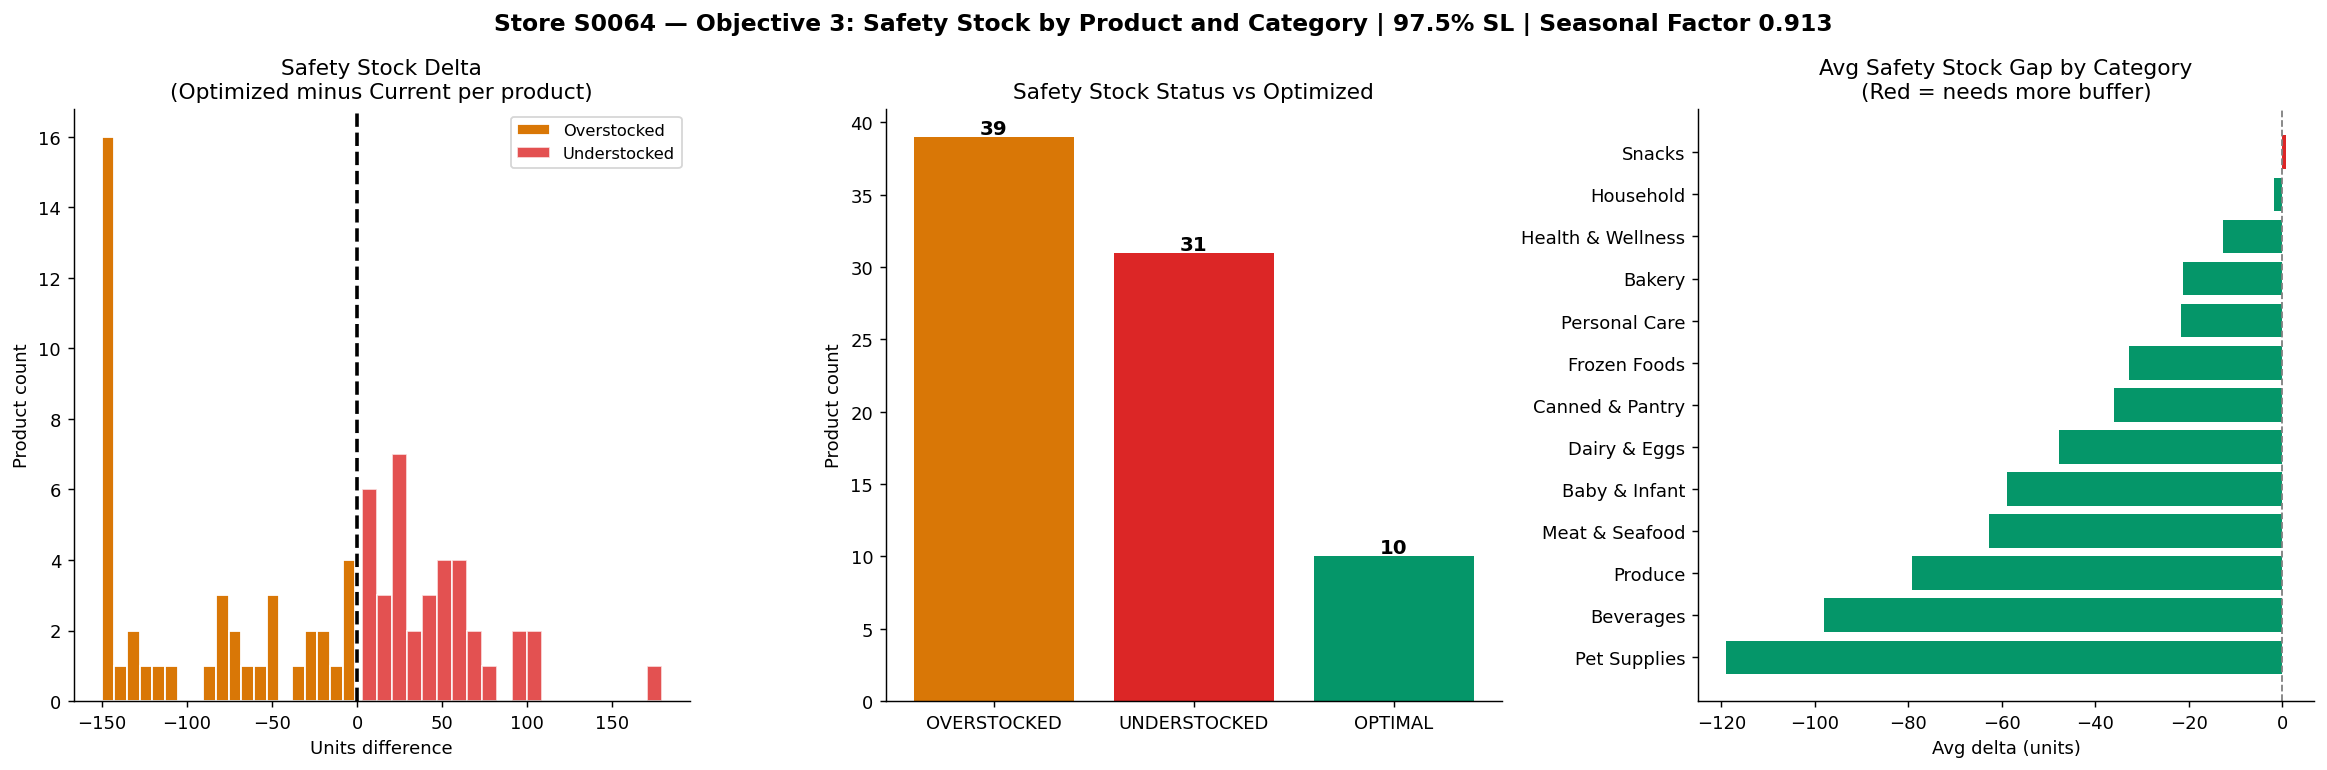

Saved: 02_safety_stock_optimization.png


In [10]:
# ── SAFETY STOCK VISUALIZATION BY CATEGORY ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'Store {FOCUS_STORE} — Objective 3: Safety Stock by Product and Category'
    f' | 97.5% SL | Seasonal Factor {seasonal_factor:.3f}',
    fontsize=13, fontweight='bold')

ax = axes[0]
dv = demand_stats['ss_delta'].clip(-150, 300)
ax.hist(dv[dv < 0],  bins=20, color=AC['WARNING'],  edgecolor='white', label='Overstocked')
ax.hist(dv[dv >= 0], bins=20, color=AC['CRITICAL'], edgecolor='white', label='Understocked', alpha=0.8)
ax.axvline(0, color='black', linestyle='--', linewidth=2)
ax.set_title('Safety Stock Delta\n(Optimized minus Current per product)')
ax.set_xlabel('Units difference')
ax.set_ylabel('Product count')
ax.legend(fontsize=9)

ax = axes[1]
sc = [AC['CRITICAL'] if s == 'UNDERSTOCKED' else
      AC['OK'] if s == 'OPTIMAL' else AC['WARNING']
      for s in status_counts.index]
bars = ax.bar(status_counts.index, status_counts.values, color=sc)
ax.set_title('Safety Stock Status vs Optimized')
ax.set_ylabel('Product count')
for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            str(val), ha='center', fontsize=11, fontweight='bold')

ax = axes[2]
cat_delta = demand_stats.groupby('category')['ss_delta'].mean().sort_values()
ccolors   = [AC['CRITICAL'] if v > 0 else AC['OK'] for v in cat_delta.values]
ax.barh(cat_delta.index, cat_delta.values, color=ccolors)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Avg Safety Stock Gap by Category\n(Red = needs more buffer)')
ax.set_xlabel('Avg delta (units)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_safety_stock_optimization.png', bbox_inches='tight')
plt.show()
print('Saved: 02_safety_stock_optimization.png')


---
## Section 7 — Phantom Inventory Detection

> **What this does:** Finds products where the system shows stock > 0 but zero units were sold that week — ghost products that exist in the computer but not on the shelf.

> **The 3-step detection logic:**
> 1. Aggregate inventory snapshots to weekly average on-hand per product
> 2. Merge with weekly sales — if no sales record exists for that week, fill with 0
> 3. Flag rows where avg_on_hand > 0 AND weekly_units == 0

> **Why we exclude slow movers:** A niche product selling 0.2 units per week having a zero-sales week is normal. We exclude the bottom 5th percentile of sellers so we only flag genuinely suspicious patterns.

> **Revenue at risk = avg_on_hand x unit_price** — conservative lower bound of what is locked up in phantom stock.

In [11]:
# ── STEP 1: Weekly inventory snapshot ────────────────────────────
s_snap['week'] = s_snap['snapshot_date'].dt.to_period('W')
snap_weekly = (
    s_snap.groupby(['sku_id','week'])
    .agg(
        avg_on_hand  = ('units_on_hand',    'mean'),
        avg_backroom = ('units_in_backroom', 'mean'),
    )
    .reset_index()
)

# ── STEP 2: Merge with weekly sales ──────────────────────────────
phantom_df = snap_weekly.merge(
    s_weekly[['sku_id','week','weekly_units']],
    on=['sku_id','week'],
    how='left'
)
phantom_df['weekly_units'] = phantom_df['weekly_units'].fillna(0)

# ── STEP 3: DETECTION RULE ───────────────────────────────────────
# system shows stock > 0 AND zero units sold that week
phantom_df['is_phantom_candidate'] = (
    (phantom_df['avg_on_hand']   > 0) &
    (phantom_df['weekly_units'] == 0)
)

# ── STEP 4: Exclude slow movers ──────────────────────────────────
sku_avg_weekly = (
    s_weekly.groupby('sku_id')['weekly_units']
    .mean()
    .reset_index()
    .rename(columns={'weekly_units': 'sku_avg_weekly'})
)
phantom_df = phantom_df.merge(sku_avg_weekly, on='sku_id', how='left')
slow_threshold = phantom_df['sku_avg_weekly'].quantile(PHANTOM_SLOW_MOVER_PCT)
slow_movers    = phantom_df['sku_avg_weekly'] < slow_threshold
phantom_df.loc[slow_movers, 'is_phantom_candidate'] = False

# ── STEP 5: Enrich with product info ─────────────────────────────
phantom_events = phantom_df[phantom_df['is_phantom_candidate']].copy()
phantom_events = phantom_events.merge(
    products[['sku_id','product_name','category','unit_price','unit_cost']],
    on='sku_id', how='left')
phantom_events['est_revenue_at_risk'] = (
    phantom_events['avg_on_hand'] * phantom_events['unit_price']
)

# ── STEP 6: Summary by product ───────────────────────────────────
phantom_by_sku = (
    phantom_events.groupby('sku_id')
    .agg(
        phantom_weeks  = ('is_phantom_candidate', 'sum'),
        avg_on_hand    = ('avg_on_hand',          'mean'),
        total_rev_risk = ('est_revenue_at_risk',   'sum'),
    )
    .sort_values('total_rev_risk', ascending=False)
    .reset_index()
)
phantom_by_sku = phantom_by_sku.merge(
    products[['sku_id','product_name','category','unit_price']],
    on='sku_id', how='left')

total_phantom_rev = phantom_events['est_revenue_at_risk'].sum()

print(f'PHANTOM INVENTORY DETECTION — Store {FOCUS_STORE}')
print(f'  Slow mover threshold    : {slow_threshold:.1f} avg units/week')
print(f'  Total snapshot-weeks    : {len(phantom_df):,}')
print(f'  Phantom candidate weeks : {phantom_df["is_phantom_candidate"].sum():,}')
print(f'  Unique phantom SKUs     : {phantom_events["sku_id"].nunique():,}')
print(f'  Est. revenue at risk    : ${total_phantom_rev:,.0f}')
print()
print('TOP PHANTOM PRODUCTS (by revenue at risk):')
print(f'  {"SKU":<10} {"Product":<32} {"Category":<18}'
      f' {"Phant Wks":>9} {"Avg On Hand":>12} {"Rev at Risk":>12}')
print(f'  {"-"*98}')
for _, r in phantom_by_sku.head(15).iterrows():
    pname = str(r.get('product_name',''))[:30]
    print(
        f'  {r["sku_id"]:<10}'
        f' {pname:<32}'
        f' {str(r["category"]):<18}'
        f' {int(r["phantom_weeks"]):>9}'
        f' {r["avg_on_hand"]:>12.1f}'
        f' ${r["total_rev_risk"]:>11,.0f}'
    )


PHANTOM INVENTORY DETECTION — Store S0064
  Slow mover threshold    : 33.9 avg units/week
  Total snapshot-weeks    : 8,400
  Phantom candidate weeks : 0
  Unique phantom SKUs     : 0
  Est. revenue at risk    : $0

TOP PHANTOM PRODUCTS (by revenue at risk):
  SKU        Product                          Category           Phant Wks  Avg On Hand  Rev at Risk
  --------------------------------------------------------------------------------------------------


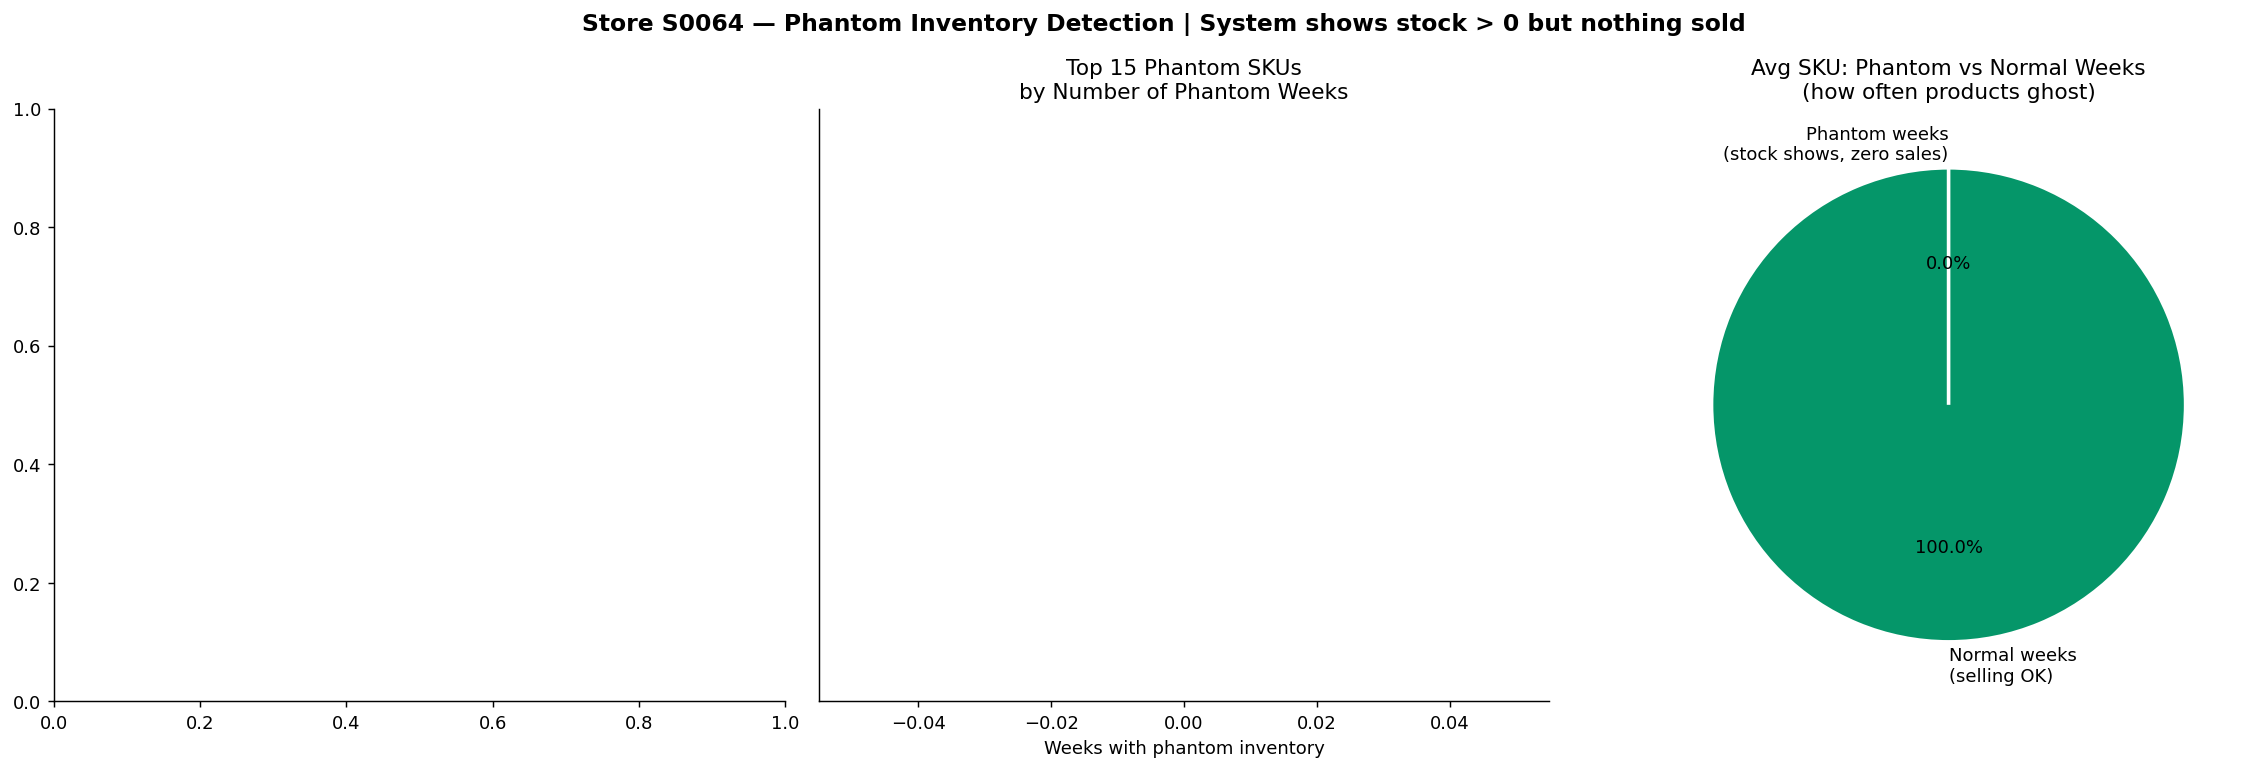

Saved: 03_phantom_inventory.png


In [12]:
# ── PHANTOM VISUALIZATION ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'Store {FOCUS_STORE} — Phantom Inventory Detection'
    f' | System shows stock > 0 but nothing sold',
    fontsize=13, fontweight='bold')

# Phantom revenue by category
ax = axes[0]
cat_ph = (
    phantom_events.groupby('category')['est_revenue_at_risk']
    .sum().sort_values(ascending=True)
)
if len(cat_ph) > 0:
    ax.barh(cat_ph.index, cat_ph.values, color=AC['PHANTOM'])
    ax.set_title('Phantom Revenue at Risk by Category\n(system shows stock, nothing selling)')
    ax.set_xlabel('Est. Revenue at Risk ($)')
    for i, v in enumerate(cat_ph.values):
        ax.text(v + 10, i, f'${v:,.0f}', va='center', fontsize=8)

# Phantom weeks per SKU (top 15)
ax = axes[1]
top_ph = phantom_by_sku.head(15)
ax.barh(range(len(top_ph)), top_ph['phantom_weeks'], color=AC['PHANTOM'])
ax.set_yticks(range(len(top_ph)))
ax.set_yticklabels(top_ph['sku_id'], fontsize=8)
ax.set_title('Top 15 Phantom SKUs\nby Number of Phantom Weeks')
ax.set_xlabel('Weeks with phantom inventory')

# Phantom vs normal weeks ratio
ax = axes[2]
total_weeks   = phantom_df.groupby('sku_id')['week'].count().mean()
phantom_weeks = phantom_df.groupby('sku_id')['is_phantom_candidate'].sum().mean()
normal_weeks  = total_weeks - phantom_weeks
ax.pie(
    [normal_weeks, phantom_weeks],
    labels=['Normal weeks\n(selling OK)', 'Phantom weeks\n(stock shows, zero sales)'],
    colors=[AC['OK'], AC['PHANTOM']],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
ax.set_title('Avg SKU: Phantom vs Normal Weeks\n(how often products ghost)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_phantom_inventory.png', bbox_inches='tight')
plt.show()
print('Saved: 03_phantom_inventory.png')


---
## Section 8 — Current Inventory Snapshot

> **What this cell does:** Pulls the most recent inventory reading for every product.

> **total_available = units_on_hand + units_in_backroom** — backroom stock can be shelved immediately so it counts toward available supply.

In [13]:
latest_snap = (
    s_snap.sort_values('snapshot_date', ascending=False)
    .groupby('sku_id').first()
    .reset_index()
    [['sku_id','snapshot_date','units_on_hand',
      'units_in_backroom','days_of_supply','expiry_nearest_date']]
)
latest_snap['total_available'] = (
    latest_snap['units_on_hand'] + latest_snap['units_in_backroom']
)
latest_snap['store_id'] = FOCUS_STORE

zero_now = (latest_snap['units_on_hand'] == 0).sum()

print(f'INVENTORY SNAPSHOT — Store {FOCUS_STORE}')
print(f'  Latest snapshot date : {latest_snap["snapshot_date"].max().date()}')
print(f'  Zero stock NOW       : {zero_now} products')
print(f'  Avg days of supply   : {latest_snap["days_of_supply"].mean():.1f} days')
print(f'  Below 7d threshold   : {(latest_snap["days_of_supply"]<7).sum()} products')
print(f'  Below 3d threshold   : {(latest_snap["days_of_supply"]<3).sum()} products')


INVENTORY SNAPSHOT — Store S0064
  Latest snapshot date : 2025-12-29
  Zero stock NOW       : 15 products
  Avg days of supply   : 15.5 days
  Below 7d threshold   : 46 products
  Below 3d threshold   : 32 products


---
## Section 9 — Live Alert Engine with Priority Ordering (Objective 4)

> **What this cell does:** Runs the complete alert engine and ranks every product by 5 reliable factors.

> **The 4 alert tiers:**
> - CRITICAL: stock = 0 OR days of supply <= 3 — order immediately
> - WARNING: days <= 7 OR stock below optimized reorder point — order today
> - MONITOR: days <= 14 — watch closely
> - OK: more than 14 days — no action needed

> **The 5 priority factors (most reliable first):**
> 1. Tier weight — CRITICAL always beats WARNING always beats MONITOR (non-negotiable)
> 2. Revenue at risk — dollars lost per day of inaction
> 3. Days of supply — lower remaining days = higher urgency within same tier
> 4. Supplier reliability — unreliable supplier means risk is higher even at same stock level
> 5. Seasonal demand — high demand month amplifies urgency

> **Why these 5 and not just revenue?** Revenue alone could rank a low-tier item above a truly critical one. Tier weight ensures operational urgency always overrides financial magnitude.

In [14]:
# ── BUILD ALERT DATAFRAME ─────────────────────────────────────────
alert_df = latest_snap.merge(
    demand_stats[[
        'sku_id','product_name','category','is_perishable',
        'avg_daily_demand','std_daily_demand','avg_demand_seasonal',
        'safety_stock_seasonal','reorder_point_optimized',
        'lead_time_final','avg_fill_rate','reliability_score',
        'total_revenue','unit_price','unit_cost','pack_size',
        'seasonal_factor','supplier_name',
    ]],
    on='sku_id', how='left')

# Days of supply — snapshot value or calculated
alert_df['days_of_supply_current'] = alert_df['days_of_supply'].fillna(
    alert_df['total_available'] /
    alert_df['avg_daily_demand'].replace(0, np.nan)
).fillna(0)

# Use seasonal demand for calculations
alert_df['demand_for_calc'] = alert_df['avg_demand_seasonal'].fillna(
    alert_df['avg_daily_demand']
)

# ── ASSIGN ALERT TIER ─────────────────────────────────────────────
def assign_alert(row):
    dos  = row['days_of_supply_current']
    hand = row['units_on_hand']
    tot  = row['total_available']
    rop  = row['reorder_point_optimized']
    if hand == 0 or dos <= CRITICAL_DAYS:
        return 'CRITICAL'
    elif dos <= WARNING_DAYS or tot <= rop:
        return 'WARNING'
    elif dos <= MONITOR_DAYS:
        return 'MONITOR'
    return 'OK'

alert_df['alert_tier'] = alert_df.apply(assign_alert, axis=1)

# ── UNITS TO ORDER ────────────────────────────────────────────────
alert_df['units_needed'] = np.ceil(
    alert_df['demand_for_calc'] * (alert_df['lead_time_final'] + TARGET_DAYS)
    - alert_df['total_available']
).clip(lower=0)

alert_df['units_to_order'] = np.ceil(
    alert_df['units_needed'] / alert_df['pack_size'].replace(0, 1)
) * alert_df['pack_size']

alert_df['units_to_order'] = alert_df['units_to_order'].where(
    alert_df['alert_tier'].isin(['CRITICAL','WARNING']), other=0
)

# ── REVENUE AT RISK ───────────────────────────────────────────────
alert_df['revenue_at_risk'] = (
    alert_df['demand_for_calc'] *
    (TARGET_DAYS - alert_df['days_of_supply_current'].clip(upper=TARGET_DAYS)) *
    alert_df['unit_price']
).clip(lower=0)

alert_df['revenue_at_risk'] = alert_df['revenue_at_risk'].where(
    alert_df['alert_tier'] != 'OK', other=0
)

# ── PHANTOM FLAG — merge phantom SKUs into alert ──────────────────
phantom_sku_set = set(phantom_by_sku['sku_id'].tolist())
alert_df['is_phantom'] = alert_df['sku_id'].isin(phantom_sku_set)

# ── 5-FACTOR PRIORITY SCORE ──────────────────────────────────────
# Factor 1: Tier weight (most important — non-negotiable ordering)
alert_df['f1_tier']     = alert_df['alert_tier'].map(TIER_WEIGHT)

# Factor 2: Revenue at risk (financial urgency)
alert_df['f2_revenue']  = alert_df['revenue_at_risk'] / REV_RISK_DIV

# Factor 3: Days of supply urgency (lower = worse)
max_dos = alert_df['days_of_supply_current'].clip(0, TARGET_DAYS).max()
alert_df['f3_dos'] = (
    (max_dos - alert_df['days_of_supply_current'].clip(0, TARGET_DAYS))
    / max(max_dos, 1) * DOS_WEIGHT
)

# Factor 4: Supplier unreliability (lower reliability = higher score)
alert_df['f4_supplier'] = (
    (1 - alert_df['reliability_score'].fillna(0.85).clip(0, 1))
    * SUPP_WEIGHT
)

# Factor 5: Seasonal demand amplifier
alert_df['f5_seasonal'] = (alert_df['seasonal_factor'].fillna(1.0) - 1) * SEASON_WEIGHT

# Combined priority score
alert_df['priority_score'] = (
    alert_df['f1_tier'] +
    alert_df['f2_revenue'] +
    alert_df['f3_dos'] +
    alert_df['f4_supplier'] +
    alert_df['f5_seasonal']
)

alert_df = alert_df.sort_values('priority_score', ascending=False).reset_index(drop=True)

tier_counts = alert_df['alert_tier'].value_counts()
total_rar   = alert_df['revenue_at_risk'].sum()
total_order = alert_df['units_to_order'].sum()

print('=' * 62)
print(f'  LIVE ALERT ENGINE — Store {FOCUS_STORE}')
print(f'  Generated: {NOW.strftime("%A, %B %d, %Y at %I:%M %p")}')
print('=' * 62)
for tier in ['CRITICAL','WARNING','MONITOR','OK']:
    cnt = tier_counts.get(tier, 0)
    pct = cnt / len(alert_df) * 100
    print(f'  {tier:<12}: {cnt:>5} products ({pct:.1f}%)')
print(f'  {"-"*40}')
print(f'  Total products         : {len(alert_df):,}')
print(f'  Total revenue at risk  : ${total_rar:,.0f}')
print(f'  Total units to order   : {int(total_order):,}')
print(f'  Phantom SKUs in alert  : {alert_df["is_phantom"].sum()}')
print(f'  Seasonal factor        : {seasonal_factor:.3f} ({month_names[TODAY.month]})')
print()
print('PRIORITY SCORE BREAKDOWN (5 factors):')
print(f'  Factor 1 Tier weight    : max {alert_df["f1_tier"].max():.0f}')
print(f'  Factor 2 Revenue risk   : max {alert_df["f2_revenue"].max():.2f}')
print(f'  Factor 3 DOS urgency    : max {alert_df["f3_dos"].max():.2f}')
print(f'  Factor 4 Supplier unreliability: max {alert_df["f4_supplier"].max():.2f}')
print(f'  Factor 5 Seasonal amp   : max {alert_df["f5_seasonal"].max():.2f}')


  LIVE ALERT ENGINE — Store S0064
  Generated: Saturday, April 25, 2026 at 01:19 PM
  CRITICAL    :    32 products (40.0%)
  MONITOR     :     4 products (5.0%)
  OK          :    24 products (30.0%)
  ----------------------------------------
  Total products         : 80
  Total revenue at risk  : $310,223
  Total units to order   : 14,983
  Phantom SKUs in alert  : 0
  Seasonal factor        : 0.913 (Apr)

PRIORITY SCORE BREAKDOWN (5 factors):
  Factor 1 Tier weight    : max 1000
  Factor 2 Revenue risk   : max 18.14
  Factor 3 DOS urgency    : max 5.00
  Factor 4 Supplier unreliability: max 5.70
  Factor 5 Seasonal amp   : max -0.87


---
## Section 10 — Category-Level Alert Drill Down

> **What this cell does:** Shows the complete alert picture broken down by product category — so the store manager can see not just which products to order but which department is in the worst shape.

> Every category shows: how many products are in each alert tier, total revenue at risk, total units to order, and which specific products are the biggest problems.

In [15]:
categories = sorted(alert_df['category'].dropna().unique())

print('=' * 75)
print(f'  CATEGORY-LEVEL ALERT DRILL DOWN — Store {FOCUS_STORE}')
print(f'  As of {NOW.strftime("%A, %B %d, %Y at %I:%M %p")}')
print('=' * 75)

cat_summary = []

for cat in categories:
    sub = alert_df[alert_df['category'] == cat]
    if len(sub) == 0:
        continue

    crit_n = (sub['alert_tier'] == 'CRITICAL').sum()
    warn_n = (sub['alert_tier'] == 'WARNING').sum()
    mon_n  = (sub['alert_tier'] == 'MONITOR').sum()
    ok_n   = (sub['alert_tier'] == 'OK').sum()
    cat_rar   = sub['revenue_at_risk'].sum()
    cat_order = sub['units_to_order'].sum()
    phantom_n = sub['is_phantom'].sum()

    cat_summary.append({
        'category'  : cat,
        'total'     : len(sub),
        'critical'  : crit_n,
        'warning'   : warn_n,
        'monitor'   : mon_n,
        'ok'        : ok_n,
        'rev_at_risk': cat_rar,
        'to_order'  : cat_order,
        'phantoms'  : phantom_n,
    })

    urgency = 'ACTION NEEDED' if crit_n > 0 else ('ORDER TODAY' if warn_n > 0 else 'WATCH')
    print(f'\n  [{urgency}] {cat}')
    print(f'    Products: {len(sub)} total | '
          f'CRIT={crit_n} | WARN={warn_n} | MON={mon_n} | OK={ok_n} | '
          f'PHANTOM={phantom_n}')
    print(f'    Revenue at risk: ${cat_rar:,.0f} | '
          f'Units to order: {int(cat_order):,}')

    urgent_products = sub[sub['alert_tier'].isin(['CRITICAL','WARNING'])].head(5)
    if len(urgent_products) > 0:
        print(f'    Top urgent products:')
        for _, r in urgent_products.iterrows():
            pname = str(r.get('product_name',''))[:35]
            ph_flag = ' [PHANTOM]' if r['is_phantom'] else ''
            print(
                f'      {r["sku_id"]} {pname:<35}'
                f' {r["alert_tier"]:<10}'
                f' DOS={r["days_of_supply_current"]:.1f}d'
                f' Order={int(r["units_to_order"])}'
                f' Risk=${r["revenue_at_risk"]:,.0f}'
                f'{ph_flag}'
            )

cat_summary_df = pd.DataFrame(cat_summary).sort_values('rev_at_risk', ascending=False)
print()
print('=' * 75)
print('CATEGORY SUMMARY TABLE (sorted by revenue at risk):')
print(cat_summary_df.to_string(index=False))


  CATEGORY-LEVEL ALERT DRILL DOWN — Store S0064
  As of Saturday, April 25, 2026 at 01:19 PM

  [ACTION NEEDED] Baby & Infant
    Products: 5 total | CRIT=2 | WARN=1 | MON=0 | OK=2 | PHANTOM=0
    Revenue at risk: $31,287 | Units to order: 1,161
    Top urgent products:
      P01125 UrbanHarvest Classic Formula 1kg    CRITICAL   DOS=0.0d Order=643 Risk=$18,137
      P01108 HearthStone Light Diapers 1kg       CRITICAL   DOS=0.0d Order=192 Risk=$1,645
      P01091 QuickFresh Classic Baby Care 500ml  WARNING    DOS=4.0d Order=326 Risk=$11,504

  [ACTION NEEDED] Bakery
    Products: 3 total | CRIT=1 | WARN=1 | MON=0 | OK=1 | PHANTOM=0
    Revenue at risk: $14,870 | Units to order: 672
    Top urgent products:
      P00439 EcoGreen Value Pack Muffins 6-Pack  CRITICAL   DOS=2.1d Order=432 Risk=$10,281
      P00451 HearthStone Pure Rolls 6-Pack       WARNING    DOS=3.6d Order=240 Risk=$4,589

  [ACTION NEEDED] Beverages
    Products: 9 total | CRIT=2 | WARN=2 | MON=0 | OK=5 | PHANTOM=0
    Re

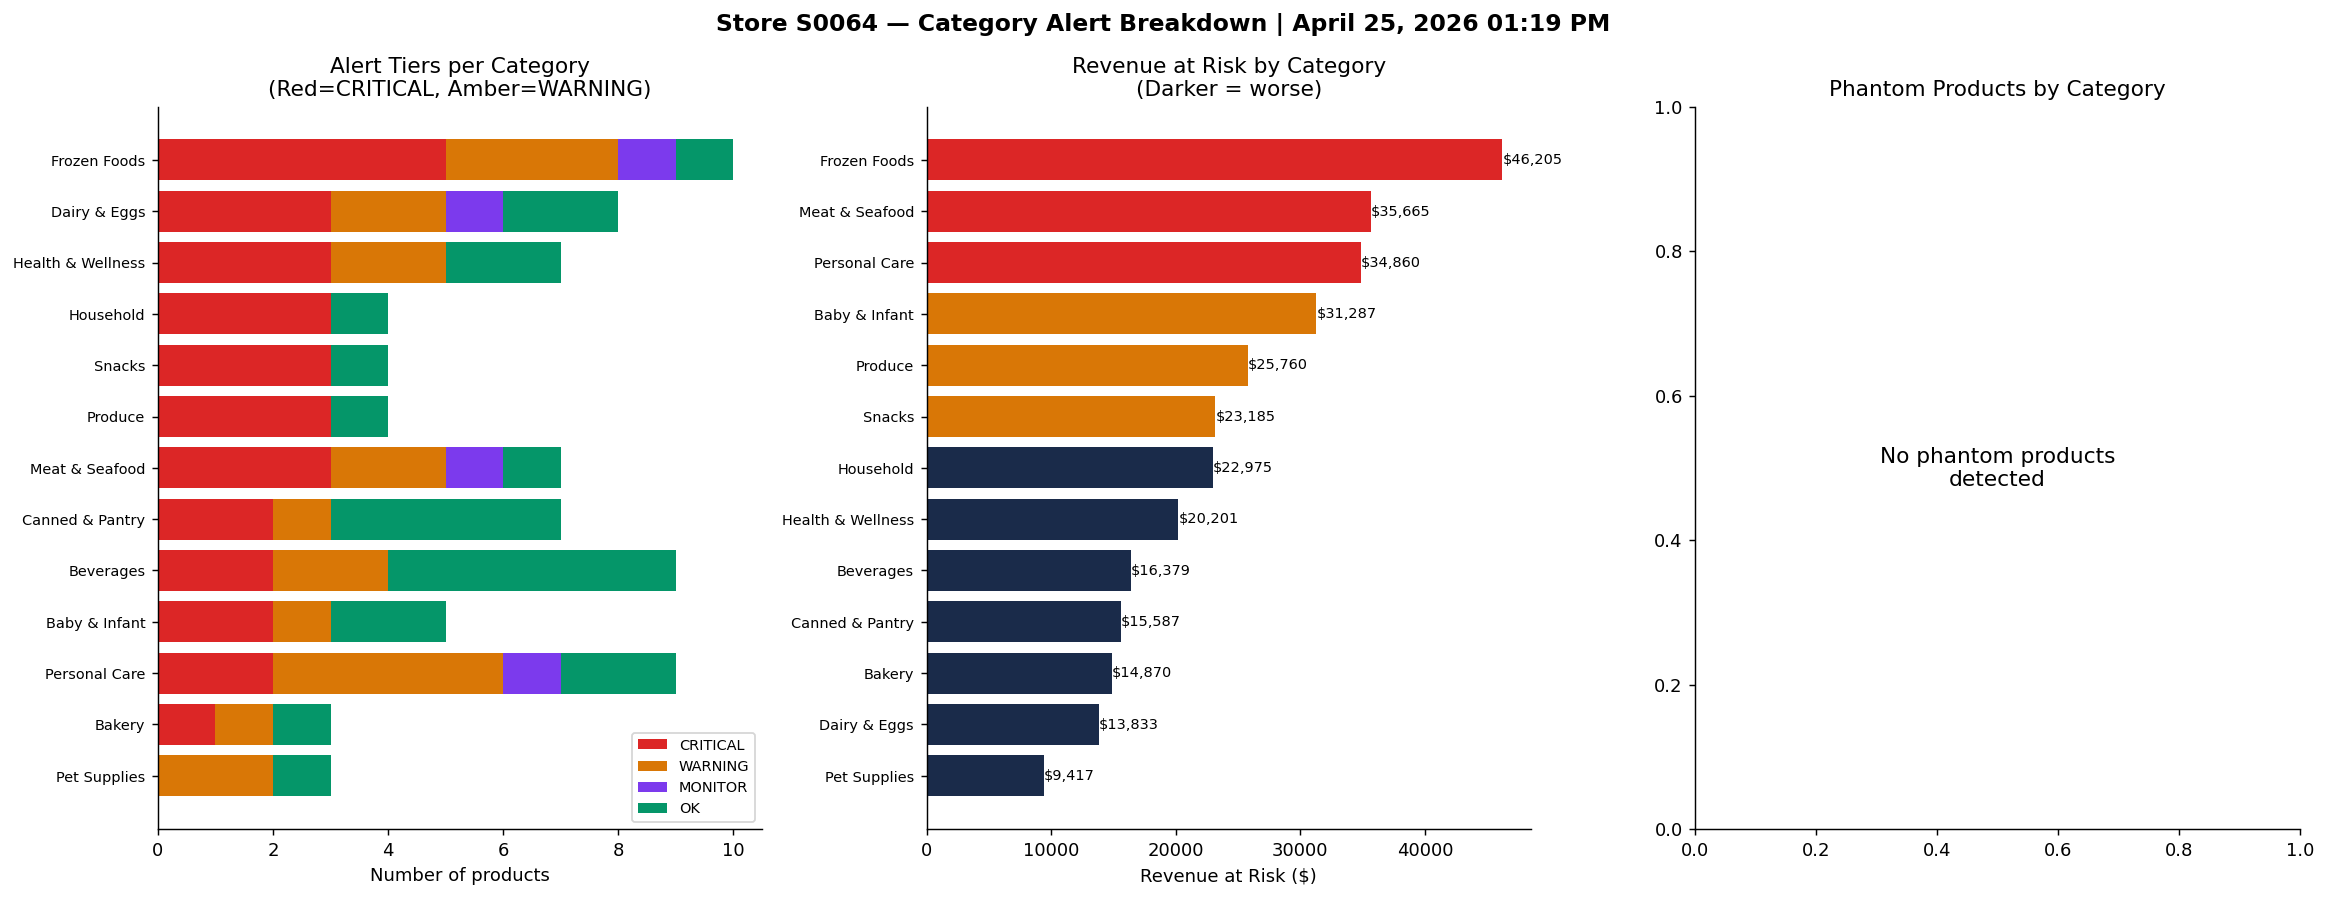

Saved: 04_category_breakdown.png


In [16]:
# ── CATEGORY VISUALIZATION ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    f'Store {FOCUS_STORE} — Category Alert Breakdown | {NOW.strftime("%B %d, %Y %I:%M %p")}',
    fontsize=13, fontweight='bold')

# Stacked bar: alert tiers per category
ax = axes[0]
cats_sorted = cat_summary_df.sort_values('critical', ascending=True)
y  = range(len(cats_sorted))
ax.barh(y, cats_sorted['critical'], color=AC['CRITICAL'], label='CRITICAL')
ax.barh(y, cats_sorted['warning'],  left=cats_sorted['critical'],
        color=AC['WARNING'], label='WARNING')
ax.barh(y, cats_sorted['monitor'],
        left=cats_sorted['critical'] + cats_sorted['warning'],
        color=AC['MONITOR'], label='MONITOR')
ax.barh(y, cats_sorted['ok'],
        left=cats_sorted['critical'] + cats_sorted['warning'] + cats_sorted['monitor'],
        color=AC['OK'], label='OK')
ax.set_yticks(y)
ax.set_yticklabels(cats_sorted['category'], fontsize=8)
ax.set_title('Alert Tiers per Category\n(Red=CRITICAL, Amber=WARNING)')
ax.set_xlabel('Number of products')
ax.legend(fontsize=8, loc='lower right')

# Revenue at risk per category
ax = axes[1]
cats_rev = cat_summary_df.sort_values('rev_at_risk', ascending=True)
rcolors  = [
    AC['CRITICAL'] if r > cats_rev['rev_at_risk'].quantile(0.75)
    else AC['WARNING'] if r > cats_rev['rev_at_risk'].median()
    else AC['navy']
    for r in cats_rev['rev_at_risk']
]
ax.barh(range(len(cats_rev)), cats_rev['rev_at_risk'], color=rcolors)
ax.set_yticks(range(len(cats_rev)))
ax.set_yticklabels(cats_rev['category'], fontsize=8)
ax.set_title('Revenue at Risk by Category\n(Darker = worse)')
ax.set_xlabel('Revenue at Risk ($)')
for i, v in enumerate(cats_rev['rev_at_risk']):
    if v > 0:
        ax.text(v + 10, i, f'${v:,.0f}', va='center', fontsize=8)

# Phantom count per category
ax = axes[2]
cats_ph = cat_summary_df[cat_summary_df['phantoms'] > 0].sort_values('phantoms')
if len(cats_ph) > 0:
    ax.barh(range(len(cats_ph)), cats_ph['phantoms'], color=AC['PHANTOM'])
    ax.set_yticks(range(len(cats_ph)))
    ax.set_yticklabels(cats_ph['category'], fontsize=8)
    ax.set_title('Phantom Products by Category\n(ghost products — system shows stock, nothing sells)')
    ax.set_xlabel('Number of phantom products')
else:
    ax.text(0.5, 0.5, 'No phantom products\ndetected', ha='center', va='center',
            transform=ax.transAxes, fontsize=12)
    ax.set_title('Phantom Products by Category')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_category_breakdown.png', bbox_inches='tight')
plt.show()
print('Saved: 04_category_breakdown.png')


---
## Section 11 — Promotion-Aware Alert Escalation

> **What this does:** Checks every alerted product against the promotions calendar for the next 7 days. Promotions can multiply demand by 1.2x to 2.8x overnight.

> **Two adjustments:**
> 1. Order quantity is multiplied by demand_lift_factor
> 2. WARNING tier automatically escalates to CRITICAL if the product is on promotion

In [17]:
active_promos = promotions[
    (promotions['start_date'] <= LOOKAHEAD) &
    (promotions['end_date']   >= TODAY)
].copy()

chain_promos = active_promos[
    active_promos['store_id'].isnull()
][['sku_id','demand_lift_factor','promotion_name','promo_type','end_date','start_date']]

store_promos = active_promos[
    active_promos['store_id'] == FOCUS_STORE
][['sku_id','demand_lift_factor','promotion_name','promo_type','end_date','start_date']]

all_promos = pd.concat(
    [chain_promos, store_promos]
).drop_duplicates('sku_id', keep='last')

alert_promo = alert_df.merge(
    all_promos.rename(columns={'end_date':'promo_end','start_date':'promo_start'}),
    on='sku_id', how='left')

alert_promo['demand_lift_factor'] = alert_promo['demand_lift_factor'].fillna(1.0)
alert_promo['is_on_promo']        = alert_promo['demand_lift_factor'] > 1.0

alert_promo['units_to_order_final'] = np.where(
    alert_promo['is_on_promo'],
    np.ceil(alert_promo['units_to_order'] * alert_promo['demand_lift_factor']),
    alert_promo['units_to_order'])

alert_promo['alert_tier_final'] = np.where(
    (alert_promo['is_on_promo']) & (alert_promo['alert_tier'] == 'WARNING'),
    'CRITICAL',
    alert_promo['alert_tier'])

promo_items = alert_promo[alert_promo['is_on_promo']]
escalated   = (
    (alert_promo['alert_tier_final'] == 'CRITICAL') &
    (alert_promo['alert_tier'] == 'WARNING')
).sum()
extra_units = (
    alert_promo['units_to_order_final'] - alert_promo['units_to_order']
).sum()

promo_sku_set = set(promo_items['sku_id'].tolist()) if len(promo_items) > 0 else set()

print(f'PROMOTION ADJUSTMENT — Promo window: Today to {LOOKAHEAD.date()}')
print(f'  SKUs on active or upcoming promo : {len(promo_items):,}')
print(f'  WARNING escalated to CRITICAL    : {escalated:,}')
print(f'  Extra units needed (promo adj)   : {extra_units:,.0f}')

if len(promo_items) > 0:
    show_cols = ['sku_id','product_name','category','alert_tier',
                 'alert_tier_final','demand_lift_factor',
                 'units_to_order','units_to_order_final','promotion_name']
    show_cols_ok = [c for c in show_cols if c in alert_promo.columns]
    print()
    print('PROMOTED ITEMS:')
    print(promo_items[show_cols_ok].head(10).to_string(index=False))


PROMOTION ADJUSTMENT — Promo window: Today to 2026-05-02
  SKUs on active or upcoming promo : 0
  WARNING escalated to CRITICAL    : 0
  Extra units needed (promo adj)   : 0


---
## Section 12 — Perishable Product Expiry Alerts

> **What this does:** For perishable products, calculates how many units will expire before they can be sold.

> **Waste risk = units_on_hand - (avg_daily_demand x days_to_expiry)**

> If we have 50 units of milk expiring in 2 days but only sell 10/day, 30 units will go to waste regardless of what the alert system says.

In [18]:
perishable_alerts = alert_df[
    (alert_df['is_perishable'] == True) &
    (alert_df['expiry_nearest_date'].notna())
].copy()

perishable_alerts['days_to_expiry'] = (
    perishable_alerts['expiry_nearest_date'] - TODAY
).dt.days

def expiry_status(days):
    if pd.isna(days):
        return 'UNKNOWN'
    elif days <= 0:
        return 'EXPIRED/TODAY'
    elif days <= 3:
        return 'EXPIRING SOON'
    elif days <= 7:
        return 'WATCH'
    return 'OK'

perishable_alerts['expiry_alert'] = perishable_alerts['days_to_expiry'].apply(expiry_status)

perishable_alerts['waste_risk_units'] = perishable_alerts.apply(
    lambda r: max(0, r['units_on_hand'] -
                  r['avg_daily_demand'] * max(0, r['days_to_expiry']))
    if pd.notna(r['days_to_expiry']) else 0, axis=1)

perishable_alerts['waste_risk_revenue'] = (
    perishable_alerts['waste_risk_units'] * perishable_alerts['unit_cost']
)

total_waste = perishable_alerts['waste_risk_revenue'].sum()

print(f'PERISHABLE EXPIRY ALERTS — Store {FOCUS_STORE}')
print(f'  As of: {NOW.strftime("%B %d, %Y at %I:%M %p")}')
print()
for status in ['EXPIRED/TODAY','EXPIRING SOON','WATCH','OK','UNKNOWN']:
    sub   = perishable_alerts[perishable_alerts['expiry_alert'] == status]
    if len(sub) == 0:
        continue
    waste = sub['waste_risk_revenue'].sum()
    print(f'  {status:<15}: {len(sub):>4} products | ${waste:>10,.0f} waste risk')
print(f'  Total waste risk: ${total_waste:,.0f}')

urgent_exp = perishable_alerts[
    perishable_alerts['expiry_alert'].isin(['EXPIRED/TODAY','EXPIRING SOON'])
].sort_values('waste_risk_revenue', ascending=False).head(10)

if len(urgent_exp) > 0:
    print()
    print('URGENT EXPIRY — TAKE ACTION TODAY:')
    print(f'  {"SKU":<10} {"Product":<30} {"Category":<18}'
          f' {"On Hand":>8} {"Days Left":>10} {"Waste $":>10}')
    print(f'  {"-"*90}')
    for _, r in urgent_exp.iterrows():
        pname = str(r.get('product_name',''))[:28]
        print(
            f'  {r["sku_id"]:<10}'
            f' {pname:<30}'
            f' {str(r["category"]):<18}'
            f' {int(r["units_on_hand"]):>8}'
            f' {int(r["days_to_expiry"]):>10}'
            f' ${r["waste_risk_revenue"]:>9,.0f}'
        )


PERISHABLE EXPIRY ALERTS — Store S0064
  As of: April 25, 2026 at 01:19 PM

  EXPIRED/TODAY  :   11 products | $    34,774 waste risk
  OK             :   21 products | $     2,078 waste risk
  Total waste risk: $36,852

URGENT EXPIRY — TAKE ACTION TODAY:
  SKU        Product                        Category            On Hand  Days Left    Waste $
  ------------------------------------------------------------------------------------------
  P00907     FreshMoment Extra Fresh Beef   Meat & Seafood          808       -115 $   17,485
  P00880     BrightBasket Deluxe Deli Mea   Meat & Seafood          259       -110 $    5,884
  P00189     BlueRidge Organic Cheese 500   Dairy & Eggs            235         -6 $    4,716
  P00248     HearthStone Original Yogurt    Dairy & Eggs            147        -64 $    2,599
  P00451     HearthStone Pure Rolls 6-Pac   Bakery                   61         -1 $    1,264
  P00439     EcoGreen Value Pack Muffins    Bakery                   68        -24 $   

---
## Section 13 — Live Morning Alert Report (Product-Level)

> **What this does:** The complete 8AM morning report the store manager reads before opening — now showing product names and categories clearly so every line is immediately actionable.

> Products are ranked by the 5-factor priority score. Phantom products and promoted products are flagged. Revenue at risk is shown for every line.

In [19]:
print('=' * 82)
print('  NEXUS | LIVE REPLENISHMENT ALERT REPORT — PRODUCT LEVEL')
print('=' * 82)
print(f'  Store       : {store_info["store_name"]} ({FOCUS_STORE})')
print(f'  Location    : {store_info["city"]}, {store_info["state"]} — {store_info["region"]}')
print(f'  Format      : {store_info["store_format"]} | Traffic: {store_info["foot_traffic_tier"]}')
print(f'  Report Time : {NOW.strftime("%A, %B %d, %Y at %I:%M %p")}')
print(f'  Season      : {month_names[TODAY.month]} demand index = {monthly_idx.get(TODAY.month,100):.1f} '
      f'(seasonal factor {seasonal_factor:.3f})')
print('=' * 82)
print(f'  {"Rank":<5} {"SKU":<10} {"Product":<28} {"Category":<16}'
      f' {"Tier":<10} {"DOS":>5} {"On Hand":>8}'
      f' {"Order":>7} {"Rev at Risk":>12} {"Flags"}')
print(f'  {"-"*115}')

for tier in ['CRITICAL','WARNING','MONITOR']:
    tier_rows = alert_df[alert_df['alert_tier'] == tier]
    if len(tier_rows) == 0:
        continue

    tier_rar = tier_rows['revenue_at_risk'].sum()
    print(f'\n  -- {tier} ({len(tier_rows)} products | ${tier_rar:,.0f} at risk) --')

    rank = 1
    for _, row in tier_rows.iterrows():
        pname    = str(row.get('product_name',''))[:26]
        cat      = str(row.get('category',''))[:14]
        dos_str  = f'{row["days_of_supply_current"]:.1f}d'
        flags    = ''
        if row['sku_id'] in promo_sku_set:
            flags += '[PROMO]'
        if row.get('is_phantom', False):
            flags += '[PHANTOM]'
        if row.get('is_perishable', False):
            flags += '[PERISH]'
        print(
            f'  {rank:<5}'
            f' {row["sku_id"]:<10}'
            f' {pname:<28}'
            f' {cat:<16}'
            f' {row["alert_tier"]:<10}'
            f' {dos_str:>5}'
            f' {int(row["units_on_hand"]):>8}'
            f' {int(row["units_to_order"]):>7}'
            f'  ${row["revenue_at_risk"]:>10,.0f}'
            f' {flags}'
        )
        rank += 1

print(f'\n{"="*82}')
print('  STORE TOTALS')
print(f'  CRITICAL : {tier_counts.get("CRITICAL",0):>5} products — ORDER IMMEDIATELY')
print(f'  WARNING  : {tier_counts.get("WARNING",0):>5} products — ORDER TODAY')
print(f'  MONITOR  : {tier_counts.get("MONITOR",0):>5} products — WATCH')
print(f'  OK       : {tier_counts.get("OK",0):>5} products — NO ACTION')
print(f'  Revenue at risk     : ${total_rar:>12,.0f}')
print(f'  Units to order NOW  : {int(total_order):>12,}')
print(f'  Promo escalations   : {escalated}')
print(f'  Phantom products    : {alert_df["is_phantom"].sum()}')
print('=' * 82)


  NEXUS | LIVE REPLENISHMENT ALERT REPORT — PRODUCT LEVEL
  Store       : GoldenSquare Houston (S0064)
  Location    : Houston, TX — Southwest
  Format      : Hypermarket | Traffic: Premium
  Report Time : Saturday, April 25, 2026 at 01:19 PM
  Season      : Apr demand index = 91.3 (seasonal factor 0.913)
  Rank  SKU        Product                      Category         Tier         DOS  On Hand   Order  Rev at Risk Flags
  -------------------------------------------------------------------------------------------------------------------

  -- CRITICAL (32 products | $221,654 at risk) --
  1     P01125     UrbanHarvest Classic Formu   Baby & Infant    CRITICAL    0.0d        0     643  $    18,137 
  2     P00981     FreshMoment Premium Mushro   Produce          CRITICAL    0.0d        0     564  $    12,476 [PERISH]
  3     P00877     EverFresh Deluxe Pork 2L     Meat & Seafood   CRITICAL    1.0d       25     468  $    10,971 [PERISH]
  4     P00605     HearthStone Bold Frozen Me   Fro

---
## Section 14 — Complete Visual Dashboard

> **What this does:** Six-panel visual dashboard covering alerts, revenue risk, seasonal context, product ranking, category breakdown, and phantom inventory — all in one image.

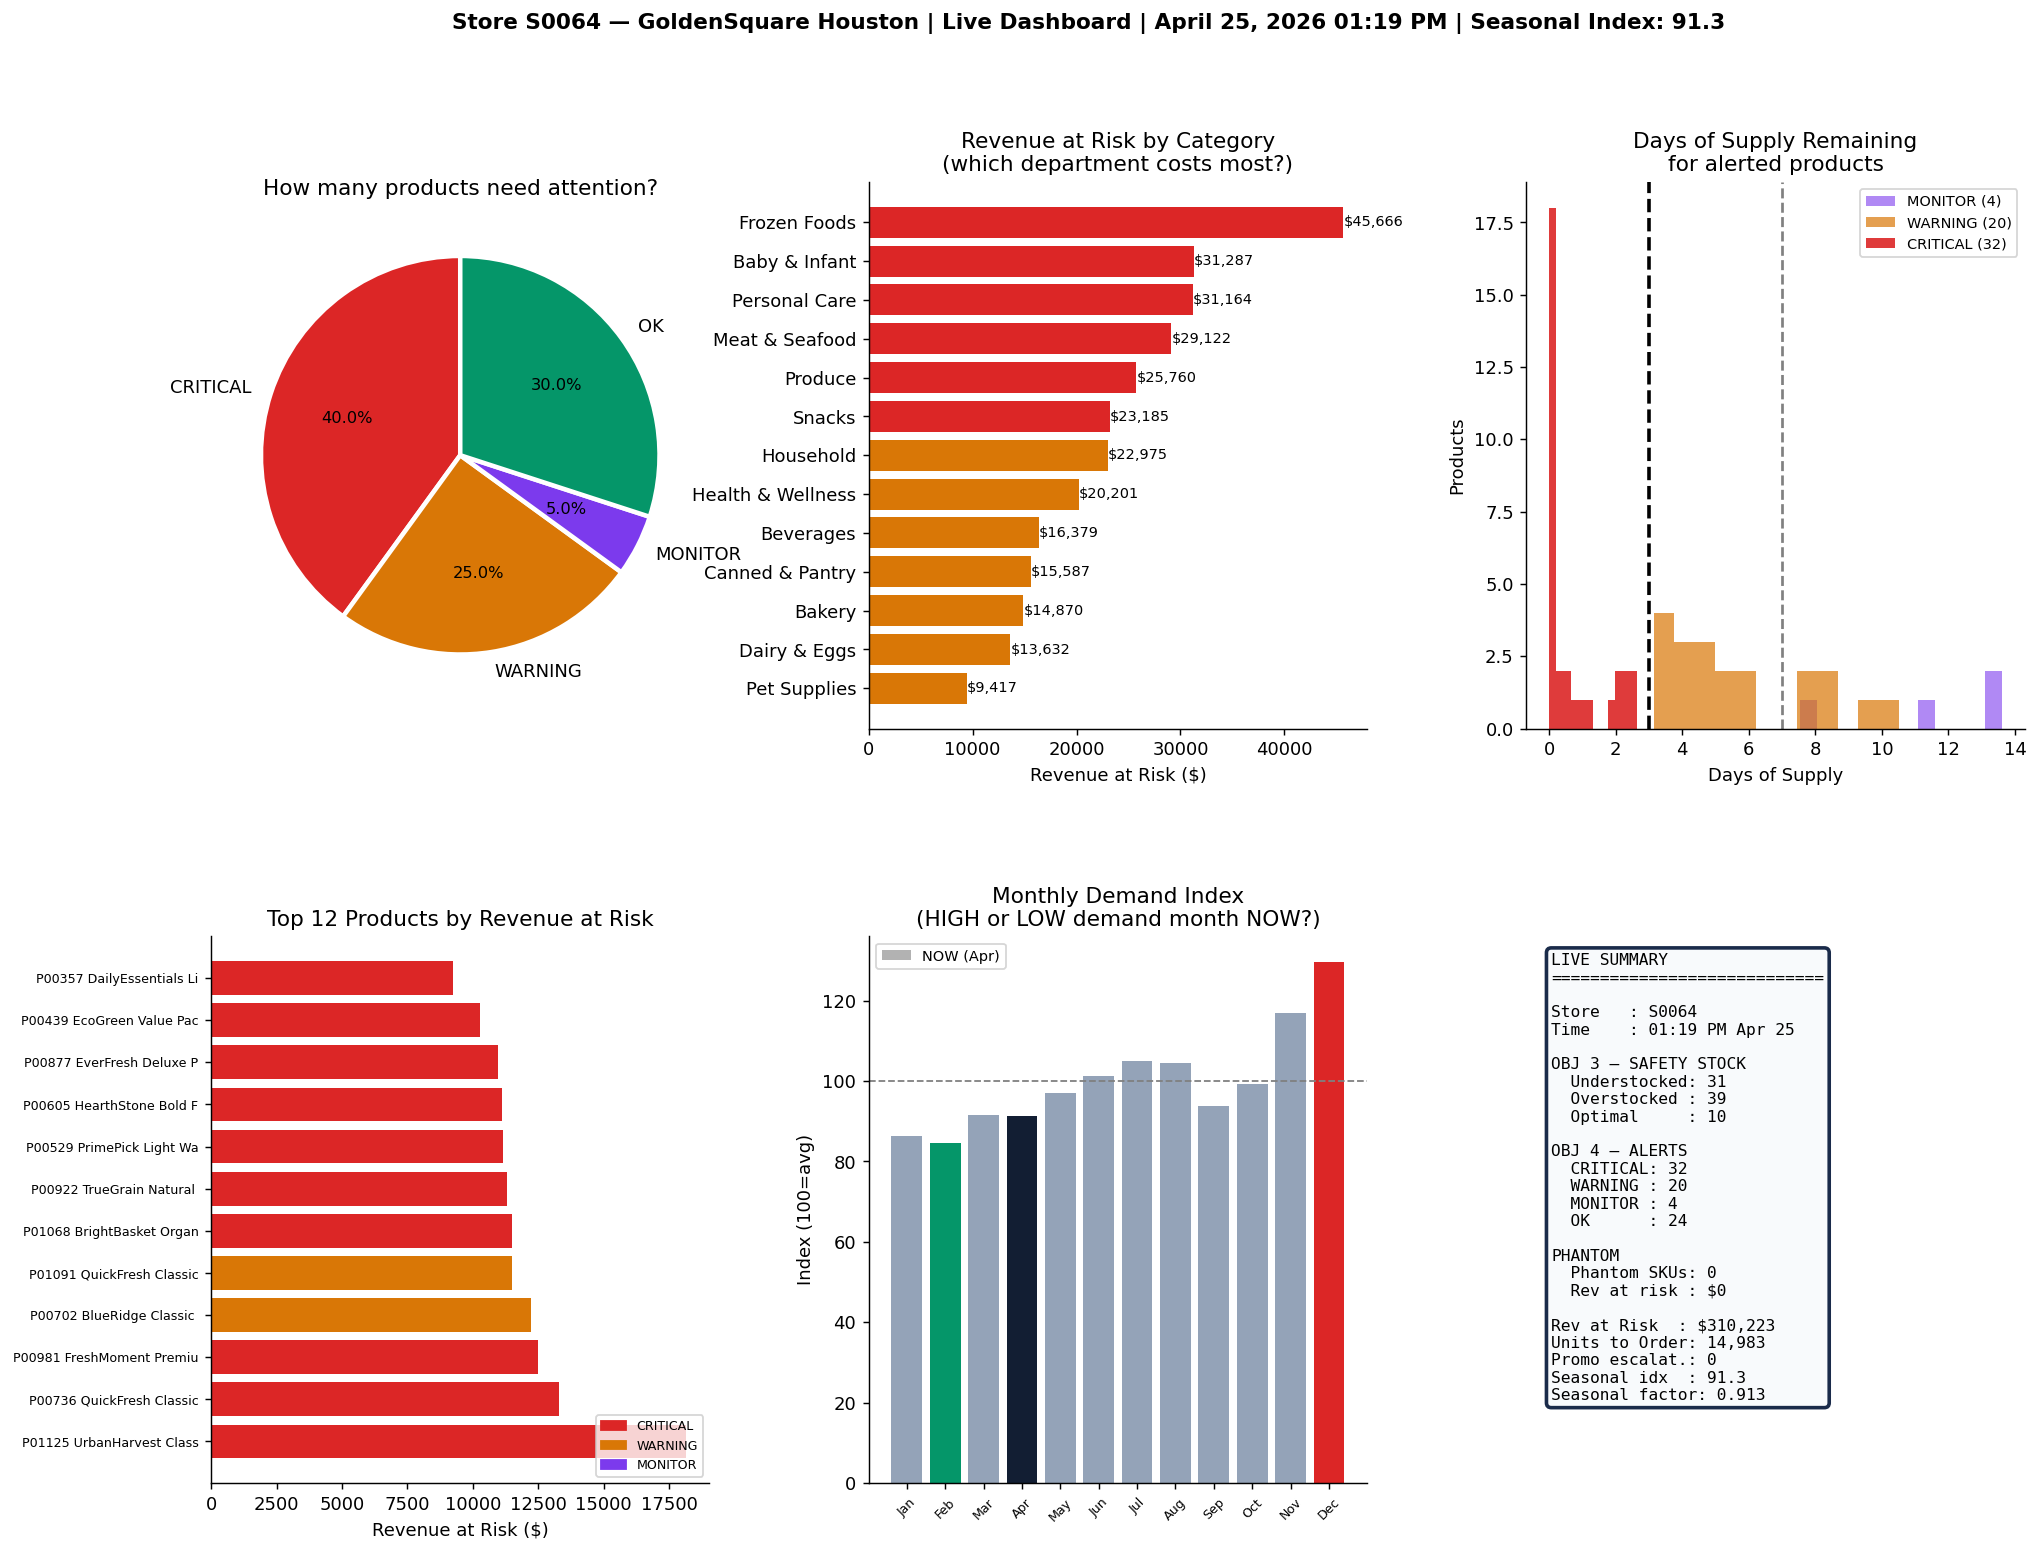

Saved: 05_live_dashboard.png


In [20]:
fig = plt.figure(figsize=(18, 13))
title_str = (
    f'Store {FOCUS_STORE} — {store_info["store_name"]} | '
    f'Live Dashboard | {NOW.strftime("%B %d, %Y %I:%M %p")} | '
    f'Seasonal Index: {monthly_idx.get(TODAY.month,100):.1f}'
)
fig.suptitle(title_str, fontsize=12, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

# Panel 1: Alert tier donut
ax1 = fig.add_subplot(gs[0, 0])
tier_order  = ['CRITICAL','WARNING','MONITOR','OK']
tier_vals   = [tier_counts.get(t, 0) for t in tier_order]
tier_colors = [AC[t] for t in tier_order]
wedges, texts, autotexts = ax1.pie(
    tier_vals, labels=tier_order, autopct='%1.1f%%',
    colors=tier_colors, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2.5})
for at in autotexts:
    at.set_fontsize(9)
ax1.set_title('How many products need attention?')

# Panel 2: Revenue at risk by category
ax2 = fig.add_subplot(gs[0, 1])
cat_rar = (
    alert_df[alert_df['alert_tier'].isin(['CRITICAL','WARNING'])]
    .groupby('category')['revenue_at_risk'].sum()
    .sort_values(ascending=True)
)
if len(cat_rar) > 0:
    bcolors = [
        AC['CRITICAL'] if v > cat_rar.median() else AC['WARNING']
        for v in cat_rar.values
    ]
    ax2.barh(cat_rar.index, cat_rar.values, color=bcolors)
    ax2.set_title('Revenue at Risk by Category\n(which department costs most?)')
    ax2.set_xlabel('Revenue at Risk ($)')
    for i, v in enumerate(cat_rar.values):
        ax2.text(v + 10, i, f'${v:,.0f}', va='center', fontsize=8)

# Panel 3: Days of supply histogram
ax3 = fig.add_subplot(gs[0, 2])
dos_c = alert_df[alert_df['alert_tier']=='CRITICAL']['days_of_supply_current'].clip(0, 20)
dos_w = alert_df[alert_df['alert_tier']=='WARNING']['days_of_supply_current'].clip(0, 20)
dos_m = alert_df[alert_df['alert_tier']=='MONITOR']['days_of_supply_current'].clip(0, 20)
ax3.hist(dos_m, bins=12, alpha=0.6, color=AC['MONITOR'], label=f'MONITOR ({len(dos_m)})')
ax3.hist(dos_w, bins=12, alpha=0.7, color=AC['WARNING'], label=f'WARNING ({len(dos_w)})')
ax3.hist(dos_c, bins=12, alpha=0.9, color=AC['CRITICAL'], label=f'CRITICAL ({len(dos_c)})')
ax3.axvline(CRITICAL_DAYS, color='black', linestyle='--', linewidth=2)
ax3.axvline(WARNING_DAYS,  color='gray',  linestyle='--', linewidth=1.5)
ax3.set_title('Days of Supply Remaining\nfor alerted products')
ax3.set_xlabel('Days of Supply')
ax3.set_ylabel('Products')
ax3.legend(fontsize=8)

# Panel 4: Top 12 products by revenue at risk
ax4 = fig.add_subplot(gs[1, 0])
top12 = alert_df[alert_df['revenue_at_risk'] > 0].nlargest(12, 'revenue_at_risk')
labels12 = [
    f'{r["sku_id"]} {str(r.get("product_name",""))[:18]}'
    for _, r in top12.iterrows()
]
bcolors12 = [AC[t] for t in top12['alert_tier']]
ax4.barh(range(len(top12)), top12['revenue_at_risk'], color=bcolors12)
ax4.set_yticks(range(len(top12)))
ax4.set_yticklabels(labels12, fontsize=7)
ax4.set_title('Top 12 Products by Revenue at Risk')
ax4.set_xlabel('Revenue at Risk ($)')
patches = [mpatches.Patch(color=AC[t], label=t) for t in ['CRITICAL','WARNING','MONITOR']]
ax4.legend(handles=patches, fontsize=7, loc='lower right')

# Panel 5: Seasonal demand context
ax5 = fig.add_subplot(gs[1, 1])
months   = list(range(1, 13))
idx_vals = [monthly_idx.get(m, 100) for m in months]
sc5 = []
for m in months:
    if m == peak_month:
        sc5.append(AC['CRITICAL'])
    elif m == low_month:
        sc5.append(AC['OK'])
    elif m == TODAY.month:
        sc5.append(AC['navy'])
    else:
        sc5.append('#94A3B8')
ax5.bar([month_names[m] for m in months], idx_vals, color=sc5)
ax5.axhline(100, color='gray', linestyle='--', linewidth=1)
curr_idx = months.index(TODAY.month)
ax5.bar(month_names[TODAY.month], idx_vals[curr_idx], color='black', alpha=0.3,
        label=f'NOW ({month_names[TODAY.month]})')
ax5.set_title('Monthly Demand Index\n(HIGH or LOW demand month NOW?)')
ax5.set_ylabel('Index (100=avg)')
ax5.tick_params(axis='x', rotation=45, labelsize=7)
ax5.legend(fontsize=8)

# Panel 6: Phantom inventory summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
ss_us = (demand_stats['ss_status'] == 'UNDERSTOCKED').sum()
ss_ov = (demand_stats['ss_status'] == 'OVERSTOCKED').sum()
ss_op = (demand_stats['ss_status'] == 'OPTIMAL').sum()
ph_ct = alert_df['is_phantom'].sum()
sumtxt = (
    f'LIVE SUMMARY\n'
    f'{"="*28}\n\n'
    f'Store   : {FOCUS_STORE}\n'
    f'Time    : {NOW.strftime("%I:%M %p %b %d")}\n\n'
    f'OBJ 3 — SAFETY STOCK\n'
    f'  Understocked: {ss_us}\n'
    f'  Overstocked : {ss_ov}\n'
    f'  Optimal     : {ss_op}\n\n'
    f'OBJ 4 — ALERTS\n'
    f'  CRITICAL: {tier_counts.get("CRITICAL",0)}\n'
    f'  WARNING : {tier_counts.get("WARNING",0)}\n'
    f'  MONITOR : {tier_counts.get("MONITOR",0)}\n'
    f'  OK      : {tier_counts.get("OK",0)}\n\n'
    f'PHANTOM\n'
    f'  Phantom SKUs: {ph_ct}\n'
    f'  Rev at risk : ${total_phantom_rev:,.0f}\n\n'
    f'Rev at Risk  : ${total_rar:,.0f}\n'
    f'Units to Order: {int(total_order):,}\n'
    f'Promo escalat.: {escalated}\n'
    f'Seasonal idx  : {monthly_idx.get(TODAY.month,100):.1f}\n'
    f'Seasonal factor: {seasonal_factor:.3f}'
)
ax6.text(0.05, 0.97, sumtxt, transform=ax6.transAxes,
         fontsize=9, fontfamily='monospace', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor=AC['light'],
                   edgecolor=AC['navy'], linewidth=2))

plt.savefig(OUTPUT_DIR / '05_live_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved: 05_live_dashboard.png')


---
## Section 15 — Step-by-Step Walkthrough: Top Priority Product

> **What this does:** Takes the single most urgent product from the alert report and walks through every formula — step by step, with plain English explanation at each step.

> This is the clearest way to demonstrate the system to any audience.

In [21]:
crit_items = alert_df[alert_df['alert_tier'] == 'CRITICAL']
if len(crit_items) == 0:
    crit_items = alert_df[alert_df['alert_tier'] == 'WARNING']

if len(crit_items) == 0:
    print('No CRITICAL or WARNING items. Store is well stocked.')
else:
    top = crit_items.iloc[0]

    D     = top['avg_daily_demand']
    Ds    = top['demand_for_calc']
    sd    = top['std_daily_demand']
    LT    = top['lead_time_final']
    slt   = top.get('lead_time_std_final', 0)
    hand  = top['units_on_hand']
    back  = top['units_in_backroom']
    tot   = top['total_available']
    dos   = top['days_of_supply_current']
    ss    = top['safety_stock_seasonal']
    rop   = top['reorder_point_optimized']
    ord_  = top['units_to_order']
    rar   = top['revenue_at_risk']
    pack  = top['pack_size']
    price = top['unit_price']
    sf    = top['seasonal_factor']
    rel   = top.get('reliability_score', 0.85)
    is_ph = top.get('is_phantom', False)
    is_pr = top['sku_id'] in promo_sku_set
    pname = str(top.get('product_name',''))[:55]

    print('=' * 70)
    print('  PRODUCT-LEVEL STEP-BY-STEP WALKTHROUGH')
    print(f'  Rank #1 Priority Product at Store {FOCUS_STORE}')
    print(f'  Report Time: {NOW.strftime("%B %d, %Y at %I:%M %p")}')
    print('=' * 70)
    print(f'  SKU      : {top["sku_id"]}')
    print(f'  Product  : {pname}')
    print(f'  Category : {top.get("category","")}')
    print(f'  Supplier : {top.get("supplier_name","")} (reliability: {rel:.2f})')
    print(f'  Price    : ${price:.2f} per unit | Pack size: {int(pack)} units/case')
    if is_ph:
        print('  *** PHANTOM FLAG: system shows stock, but historically zero sales ***')
    if is_pr:
        print('  *** PROMOTION FLAG: active or upcoming promotion within 7 days ***')
    print()

    print('─' * 70)
    print('STEP 1 — Current shelf situation')
    print('─' * 70)
    print(f'  Units on shelf    : {int(hand)}')
    print(f'  Units in backroom : {int(back)}')
    print(f'  Total available   : {int(tot)}')
    print(f'  Avg daily demand  : {D:.1f} units/day (historical avg)')
    print(f'  Seasonal factor   : {sf:.3f} ({month_names[TODAY.month]} index = {sf*100:.1f})')
    print(f'  Seasonal demand   : {Ds:.1f} units/day (adjusted for this month)')
    print(f'  Days of supply    : {int(tot)} / {D:.1f} = {dos:.1f} days')
    print(f'  Interpretation    : shelf runs empty in {dos:.1f} days')
    print()

    print('─' * 70)
    print(f'STEP 2 — Why {top["alert_tier"]}?')
    print('─' * 70)
    if hand == 0:
        print('  units_on_hand == 0 — shelf is ALREADY EMPTY right now')
    elif dos <= CRITICAL_DAYS:
        print(f'  days_of_supply ({dos:.1f}) <= CRITICAL threshold ({CRITICAL_DAYS})')
        print(f'  Supplier takes {LT:.1f} days. Stock lasts {dos:.1f} days.')
        print('  STOCKOUT IS GUARANTEED before next delivery arrives')
    elif dos <= WARNING_DAYS:
        print(f'  days_of_supply ({dos:.1f}) <= WARNING threshold ({WARNING_DAYS})')
        print('  Must order today to avoid running out during lead time')
    elif tot <= rop:
        print(f'  total_available ({int(tot)}) <= reorder_point ({int(rop)})')
        print('  Stock has crossed the trigger level — order now')
    print()

    print('─' * 70)
    print('STEP 3 — Safety Stock (how much buffer to hold)')
    print('─' * 70)
    t1 = LT * sd**2
    t2 = D**2 * slt**2
    inner = max(t1 + t2, 0.001)
    ss_raw = Z_SCORE * np.sqrt(inner)
    print('  Formula: Z x sqrt( LT x sd2 + D2 x slt2 )')
    print(f'  Z   = {Z_SCORE:.4f}  (97.5% service level, Section 7 Data Guide)')
    print(f'  LT  = {LT:.1f} days  (actual avg lead time)')
    print(f'  sd  = {sd:.1f} units  (demand std deviation)')
    print(f'  slt = {slt:.1f} days  (lead time std deviation)')
    print(f'  Term 1: {LT:.1f} x {sd:.1f}2 = {t1:.2f}  (demand risk while waiting)')
    print(f'  Term 2: {D:.1f}2 x {slt:.1f}2 = {t2:.2f}  (late supplier risk)')
    print(f'  sqrt({inner:.2f}) = {np.sqrt(inner):.4f}')
    print(f'  x Z = {ss_raw:.2f}')
    print(f'  x seasonal factor ({sf:.3f}) = {ss_raw*sf:.2f}')
    print(f'  Round UP = {int(ss)} units  (SAFETY STOCK)')
    print()

    print('─' * 70)
    print('STEP 4 — Reorder Point')
    print('─' * 70)
    dlt = D * LT
    print('  Formula: (D x LT) + Safety Stock')
    print(f'  D x LT = {D:.1f} x {LT:.1f} = {dlt:.1f}  (units sold while waiting for delivery)')
    print(f'  + Safety Stock = {int(ss)}')
    print(f'  = Reorder Point = {int(rop)} units')
    print(f'  We have {int(tot)} available. {int(tot)} < {int(rop)} confirms we must order now')
    print()

    print('─' * 70)
    print('STEP 5 — Units to Order')
    print('─' * 70)
    need_total = Ds * (LT + TARGET_DAYS)
    net_needed = max(0, need_total - tot)
    cases      = np.ceil(net_needed / pack)
    u_ordered  = cases * pack
    print('  Formula: ceil( (D x (LT + 14)) - available ) / pack_size ) x pack_size')
    print(f'  Ds x (LT + 14) = {Ds:.1f} x ({LT:.1f} + 14) = {need_total:.1f}  (total needed)')
    print(f'  - available ({int(tot)}) = {net_needed:.1f} units needed')
    print(f'  / pack_size ({int(pack)}) = {net_needed/pack:.2f} cases')
    print(f'  Round UP to {int(cases)} cases x {int(pack)} = {int(u_ordered)} units')
    if is_pr:
        pr_row = promo_items[promo_items['sku_id'] == top['sku_id']]
        if len(pr_row):
            lift = pr_row.iloc[0]['demand_lift_factor']
            padj = np.ceil(u_ordered * lift)
            print(f'  PROMO ADJUSTMENT: x {lift:.2f} lift = {int(padj)} units to order')
    print()

    print('─' * 70)
    print('STEP 6 — Revenue at Risk (cost of doing nothing)')
    print('─' * 70)
    missing = TARGET_DAYS - min(dos, TARGET_DAYS)
    print('  Formula: D x (14 - days_of_supply) x unit_price')
    print(f'  Missing days = 14 - {dos:.1f} = {missing:.1f} days of lost sales')
    print(f'  {Ds:.1f} x {missing:.1f} x ${price:.2f} = ${rar:,.0f}')
    print(f'  REVENUE AT RISK = ${rar:,.0f}')
    print(f'  Every day of inaction costs ~${Ds*price:,.0f}')
    print()

    print('─' * 70)
    print('STEP 7 — Why is this product ranked #1? (5-Factor Priority)')
    print('─' * 70)
    f1 = TIER_WEIGHT.get(top['alert_tier'], 0)
    f2 = rar / REV_RISK_DIV
    f3 = top.get('f3_dos', 0)
    f4 = top.get('f4_supplier', 0)
    f5 = top.get('f5_seasonal', 0)
    total_ps = f1 + f2 + f3 + f4 + f5
    print(f'  Factor 1 — Tier weight     : {f1:.2f}  (CRITICAL=1000 always beats WARNING=100)')
    print(f'  Factor 2 — Revenue risk    : {f2:.2f}  (${rar:,.0f} / 1000)')
    print(f'  Factor 3 — DOS urgency     : {f3:.2f}  (lower days = higher score)')
    print(f'  Factor 4 — Supplier unreliability: {f4:.2f}  (reliability={rel:.2f})')
    print(f'  Factor 5 — Seasonal demand : {f5:.2f}  (factor={sf:.3f})')
    print(f'  TOTAL PRIORITY SCORE = {total_ps:.2f}')
    print()

    print('=' * 70)
    print('PLAIN ENGLISH SUMMARY FOR STORE MANAGER')
    print('=' * 70)
    print(f'  {top["sku_id"]} ({top.get("category","")}) — {pname}')
    print(f'  Only {dos:.1f} days of stock left. Supplier takes {LT:.0f} days.')
    print(f'  You WILL run out before the next delivery.')
    print(f'  ORDER {int(ord_)} units ({int(cases)} cases) RIGHT NOW.')
    print(f'  Every day you wait costs ${Ds*price:,.0f} in lost sales.')
    print('=' * 70)


  PRODUCT-LEVEL STEP-BY-STEP WALKTHROUGH
  Rank #1 Priority Product at Store S0064
  Report Time: April 25, 2026 at 01:19 PM
  SKU      : P01125
  Product  : UrbanHarvest Classic Formula 1kg
  Category : Baby & Infant
  Supplier : Harvest Partners LLC (reliability: 0.84)
  Price    : $49.93 per unit | Pack size: 1 units/case

──────────────────────────────────────────────────────────────────────
STEP 1 — Current shelf situation
──────────────────────────────────────────────────────────────────────
  Units on shelf    : 0
  Units in backroom : 0
  Total available   : 0
  Avg daily demand  : 28.4 units/day (historical avg)
  Seasonal factor   : 0.913 (Apr index = 91.3)
  Seasonal demand   : 25.9 units/day (adjusted for this month)
  Days of supply    : 0 / 28.4 = 0.0 days
  Interpretation    : shelf runs empty in 0.0 days

──────────────────────────────────────────────────────────────────────
STEP 2 — Why CRITICAL?
──────────────────────────────────────────────────────────────────────
  

---
## Section 16 — Export All Results

In [22]:
store_out = OUTPUT_DIR / FOCUS_STORE
store_out.mkdir(exist_ok=True)

# Master alert with product names
export_cols = [
    'sku_id','product_name','category','is_perishable','is_phantom',
    'alert_tier','days_of_supply_current','units_on_hand','units_in_backroom',
    'total_available','reorder_point_optimized','safety_stock_seasonal',
    'avg_daily_demand','demand_for_calc','lead_time_final','reliability_score',
    'units_to_order','revenue_at_risk','priority_score',
    'f1_tier','f2_revenue','f3_dos','f4_supplier','f5_seasonal',
    'snapshot_date'
]
export_ok = [c for c in export_cols if c in alert_df.columns]
master = alert_df[export_ok].copy()
master.insert(0, 'store_id', FOCUS_STORE)
master.insert(0, 'report_time', NOW.strftime('%Y-%m-%d %H:%M:%S'))
master.to_csv(store_out / 'live_alert_report.csv', index=False)
print(f'Exported: live_alert_report.csv ({len(master):,} rows)')

for tier in ['CRITICAL','WARNING','MONITOR']:
    sub = master[master['alert_tier'] == tier]
    sub.to_csv(store_out / f'alerts_{tier.lower()}.csv', index=False)
    print(f'  {tier:<10}: {len(sub):,} rows')

# Phantom inventory
phantom_out = phantom_by_sku.copy()
phantom_out.insert(0, 'store_id', FOCUS_STORE)
phantom_out.to_csv(store_out / 'phantom_inventory.csv', index=False)
print(f'  Phantom inventory -> phantom_inventory.csv ({len(phantom_out):,} SKUs)')

# Optimized reorder points
rop_out = demand_stats[[
    'sku_id','product_name','category',
    'avg_daily_demand','std_daily_demand','lead_time_final',
    'safety_stock','safety_stock_optimized','safety_stock_seasonal',
    'ss_delta','ss_status',
    'reorder_point','reorder_point_optimized','rop_delta','avg_fill_rate'
]].copy()
rop_out.insert(0, 'store_id', FOCUS_STORE)
rop_out.to_csv(store_out / 'optimized_reorder_points.csv', index=False)
print(f'  Obj 3 output -> optimized_reorder_points.csv ({len(rop_out):,} rows)')

# Category summary
cat_summary_df.to_csv(store_out / 'category_alert_summary.csv', index=False)
print(f'  Category summary -> category_alert_summary.csv')

# Perishable
if len(perishable_alerts) > 0:
    perishable_alerts[[
        'sku_id','product_name','category','units_on_hand',
        'days_to_expiry','expiry_alert','waste_risk_units','waste_risk_revenue'
    ]].to_csv(store_out / 'perishable_expiry_alerts.csv', index=False)
    print(f'  Perishable -> perishable_expiry_alerts.csv')

print(f'\nAll outputs saved to: {store_out.resolve()}/')


Exported: live_alert_report.csv (80 rows)
  CRITICAL  : 32 rows
  MONITOR   : 4 rows
  Phantom inventory -> phantom_inventory.csv (0 SKUs)
  Obj 3 output -> optimized_reorder_points.csv (80 rows)
  Category summary -> category_alert_summary.csv
  Perishable -> perishable_expiry_alerts.csv

All outputs saved to: /Users/shashi/retail-ai-project/notebooks/nexus_alert_outputs/S0064/


---
## Section 17 — Executive Summary

In [23]:
crit_c = tier_counts.get('CRITICAL', 0)
warn_c = tier_counts.get('WARNING',  0)
mon_c  = tier_counts.get('MONITOR',  0)
ok_c   = tier_counts.get('OK',       0)
us_c   = (demand_stats['ss_status'] == 'UNDERSTOCKED').sum()
ov_c   = (demand_stats['ss_status'] == 'OVERSTOCKED').sum()
op_c   = (demand_stats['ss_status'] == 'OPTIMAL').sum()

print('=' * 70)
print('  NEXUS | EXECUTIVE SUMMARY')
print('  Objectives 3 & 4 + Phantom Inventory Detection')
print('=' * 70)
print(f'  Store    : {FOCUS_STORE} — {store_info["store_name"]}')
print(f'  Location : {store_info["city"]}, {store_info["state"]} | {store_info["store_format"]}')
print(f'  Time     : {NOW.strftime("%A, %B %d, %Y at %I:%M %p")}')
print()
print('  CONFIGURATION')
print(f'  Service Level  : {SERVICE_LEVEL*100:.1f}%  Z = {Z_SCORE:.4f}')
print(f'  Seasonal Factor: {seasonal_factor:.3f} ({month_names[TODAY.month]} index = {monthly_idx.get(TODAY.month,100):.1f})')
print(f'  Thresholds     : CRITICAL<={CRITICAL_DAYS}d | WARNING<={WARNING_DAYS}d | MONITOR<={MONITOR_DAYS}d')
print()
print('  OBJECTIVE 3 — SAFETY STOCK')
print(f'  Products analyzed   : {len(demand_stats):,}')
print(f'  UNDERSTOCKED        : {us_c:,} (need more buffer at 97.5% SL)')
print(f'  OVERSTOCKED         : {ov_c:,} (holding excess — free up capital)')
print(f'  OPTIMAL             : {op_c:,} (within 10 units of formula)')
print(f'  Avg optimized SS    : {demand_stats["safety_stock_seasonal"].mean():.1f} units')
print(f'  Avg current SS      : {demand_stats["safety_stock"].mean():.1f} units')
print()
print('  OBJECTIVE 4 — LIVE ALERT ENGINE')
print(f'  CRITICAL (order NOW): {crit_c:,} products')
print(f'  WARNING  (order TODAY): {warn_c:,} products')
print(f'  MONITOR  (watch)    : {mon_c:,} products')
print(f'  OK       (no action): {ok_c:,} products')
print(f'  Total revenue at risk : ${total_rar:,.0f}')
print(f'  Total units to order  : {int(total_order):,}')
print(f'  Promo escalations     : {escalated}')
print()
print('  PHANTOM INVENTORY')
print(f'  Phantom SKUs flagged  : {phantom_events["sku_id"].nunique():,}')
print(f'  Est. revenue at risk  : ${total_phantom_rev:,.0f}')
print(f'  Slow mover threshold  : {slow_threshold:.1f} avg units/week')
print()
print('  HISTORICAL CONTEXT')
print(f'  Past stockout events  : {len(s_so):,}')
print(f'  Past lost revenue     : ${s_so["estimated_lost_revenue"].sum():,.0f}')
print(f'  Avg stockout duration : {s_so["duration_days"].mean():.1f} days')
print()
print('  OUTPUT FILES')
print(f'  live_alert_report.csv          — full product-level ranked alert')
print(f'  alerts_critical.csv            — order immediately')
print(f'  alerts_warning.csv             — order today')
print(f'  alerts_monitor.csv             — watch list')
print(f'  phantom_inventory.csv          — ghost product list')
print(f'  optimized_reorder_points.csv   — Objective 3 deliverable')
print(f'  category_alert_summary.csv     — category drill down')
print(f'  perishable_expiry_alerts.csv   — expiry warnings')
print('=' * 70)


  NEXUS | EXECUTIVE SUMMARY
  Objectives 3 & 4 + Phantom Inventory Detection
  Store    : S0064 — GoldenSquare Houston
  Location : Houston, TX | Hypermarket
  Time     : Saturday, April 25, 2026 at 01:19 PM

  CONFIGURATION
  Service Level  : 97.5%  Z = 1.9600
  Seasonal Factor: 0.913 (Apr index = 91.3)
  Thresholds     : CRITICAL<=3d | WARNING<=7d | MONITOR<=14d

  OBJECTIVE 3 — SAFETY STOCK
  Products analyzed   : 80
  UNDERSTOCKED        : 31 (need more buffer at 97.5% SL)
  OVERSTOCKED         : 39 (holding excess — free up capital)
  OPTIMAL             : 10 (within 10 units of formula)
  Avg optimized SS    : 72.7 units
  Avg current SS      : 117.8 units

  OBJECTIVE 4 — LIVE ALERT ENGINE
  CRITICAL (order NOW): 32 products
  WARNING  (order TODAY): 20 products
  MONITOR  (watch)    : 4 products
  OK       (no action): 24 products
  Total revenue at risk : $310,223
  Total units to order  : 14,983
  Promo escalations     : 0

  PHANTOM INVENTORY
  Phantom SKUs flagged  : 0
  Es